Sinal Freqs Ajustadas: [82.03125  83.984375 85.9375   87.890625 89.84375  91.796875 93.75
 95.703125]
Ruído (H1) Freqs Ajustadas: [ 41.015625  50.78125   60.546875  70.3125   101.5625   111.328125
 121.09375  130.859375]
FP Ref (H0) Freqs Ajustadas: [ 41.015625  50.78125   60.546875  70.3125   101.5625   111.328125
 121.09375  130.859375]
Calculando limiar da MSC e PFA/TN global (H0)...
  H0 trial 1000/10000
  H0 trial 2000/10000
  H0 trial 3000/10000
  H0 trial 4000/10000
  H0 trial 5000/10000
  H0 trial 6000/10000
  H0 trial 7000/10000
  H0 trial 8000/10000
  H0 trial 9000/10000
  H0 trial 10000/10000
Limiar MSC: 0.4293 (Tempo H0: 6.98s)
PFA Empírica Global (H0): 0.0500
TN Rate Global (H0 - Especificidade): 0.9500
Calculando PD/FN (Sinal) e FP/TN (Ruído em H1)...
  SNR=-25.0dB: PD_M=0.006, FP_H1_M=0.0069
  SNR=-23.0dB: PD_M=0.009, FP_H1_M=0.0069
  SNR=-21.0dB: PD_M=0.008, FP_H1_M=0.0073
  SNR=-19.0dB: PD_M=0.007, FP_H1_M=0.0046
  SNR=-17.0dB: PD_M=0.009, FP_H1_M=0.0071
  SNR=-15.0dB:

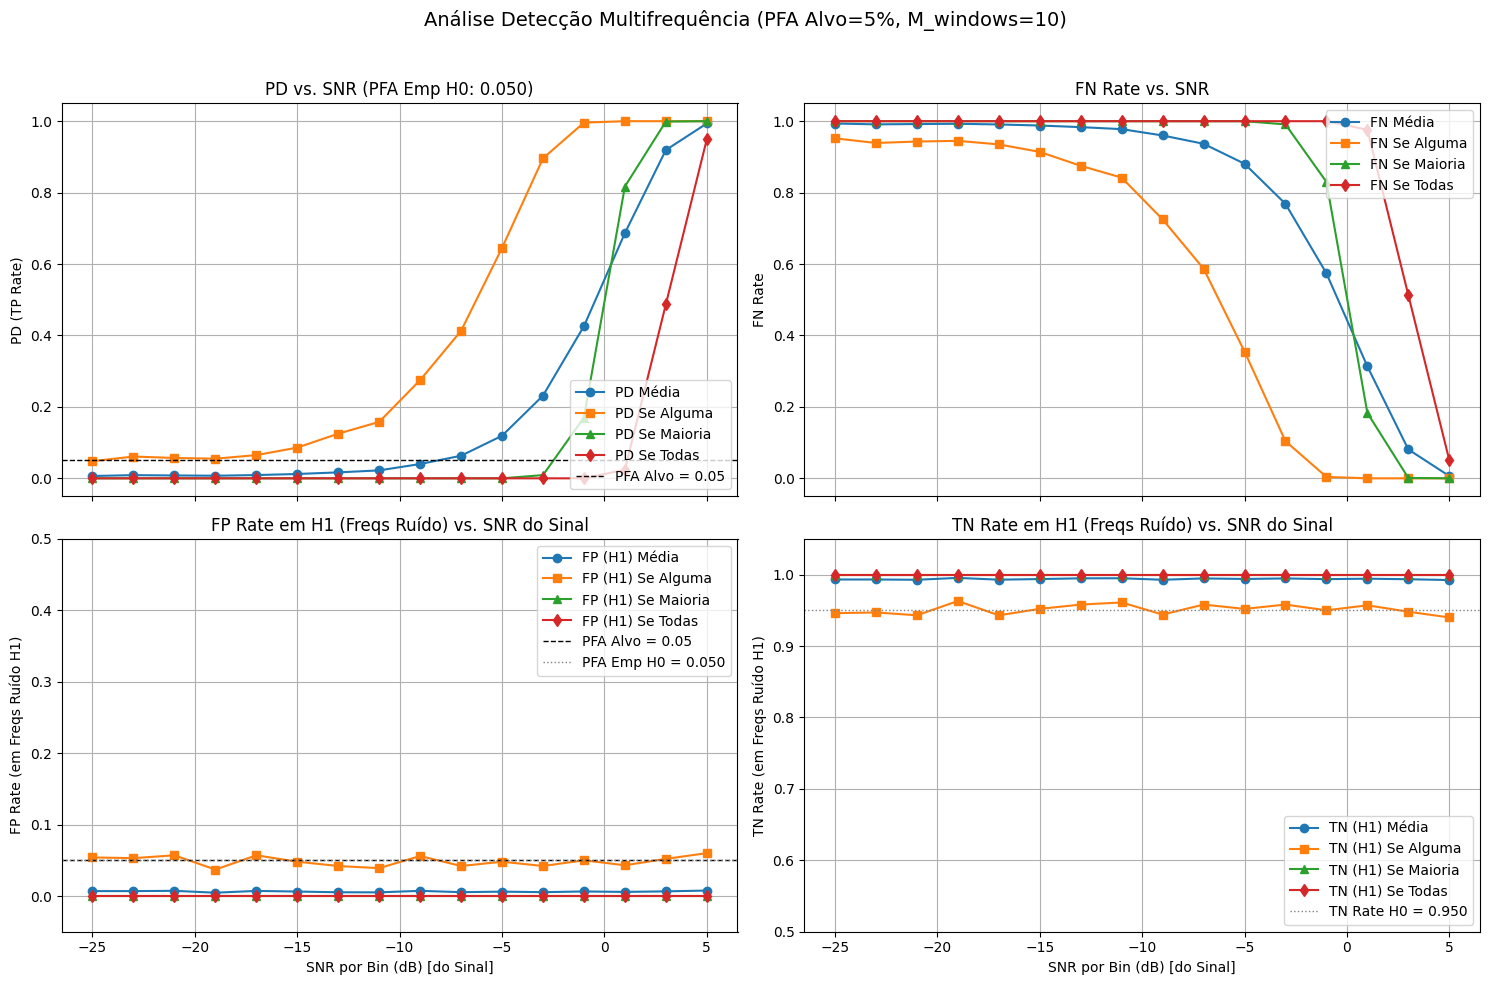

Simulação com análise completa concluída.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, scoreatpercentile
import time

# --- Funções Auxiliares (msc_fft_py e wilson_score_interval_py da resposta anterior) ---
def msc_fft_py(Y_input, M_win):
    if Y_input.shape[1] == 0 or M_win == 0: return np.zeros(Y_input.shape[0])
    current_M_win = min(M_win, Y_input.shape[1])
    if current_M_win == 0: return np.zeros(Y_input.shape[0])
    if current_M_win == 1: return np.ones(Y_input.shape[0])
    Y_to_use = Y_input[:, :current_M_win]
    numerator = np.abs(np.sum(Y_to_use, axis=1))**2
    denominator = current_M_win * np.sum(np.abs(Y_to_use)**2, axis=1)
    msc = np.zeros_like(numerator, dtype=float)
    valid_den = denominator != 0
    msc[valid_den] = numerator[valid_den] / denominator[valid_den]
    msc[np.isnan(msc)] = 0; msc[np.isinf(msc)] = 0
    return msc

def wilson_score_interval_py(k, n, confidence_level=0.95):
    if n == 0 or np.isnan(n) or np.isnan(k): return np.nan, (np.nan, np.nan)
    k = np.nan_to_num(k) # Tratar NaN em k, se houver
    alpha = 1 - confidence_level; z = norm.ppf(1 - alpha / 2)
    phat = k / n
    term1 = phat + (z**2) / (2 * n)
    term2 = z * np.sqrt((phat * (1 - phat) / n) + (z**2) / (4 * n**2))
    denominator = 1 + (z**2) / n
    pci_l = max(0, (term1 - term2) / denominator)
    pci_u = min(1, (term1 + term2) / denominator)
    return phat, (pci_l, pci_u)

# --- Parâmetros da Simulação ---
FS = 1000; NFFT_msc = 512; M_windows = 10
signal_frequencies_nominal = np.array([82, 84, 86, 88, 90, 92, 94, 96])
noise_only_frequencies_nominal = np.array([41, 51, 61, 71, 101, 111, 121, 131])
fp_reference_frequencies_nominal = noise_only_frequencies_nominal.copy()

num_signal_freqs = len(signal_frequencies_nominal)
num_noise_only_freqs = len(noise_only_frequencies_nominal)
num_fp_ref_freqs = len(fp_reference_frequencies_nominal)

target_pfa = 0.05
N_trials_H0 = 10000
N_master_trials_H1 = 1000
snr_db_per_bin_range = np.arange(-25, 5 + 1, 2)

total_samples_msc = NFFT_msc * M_windows
t_msc_segment = np.arange(NFFT_msc) / FS
hanning_win_msc = np.hanning(NFFT_msc)

def adjust_freqs_get_bins_py(nominal_freqs, NFFT, FS_rate):
    adj_freqs = np.zeros_like(nominal_freqs, dtype=float)
    bin_indices = np.zeros_like(nominal_freqs, dtype=int)
    for i, f_val in enumerate(nominal_freqs):
        bin_idx_ideal = int(round(f_val * NFFT / FS_rate))
        adj_freqs[i] = bin_idx_ideal * FS_rate / NFFT
        bin_indices[i] = bin_idx_ideal # Para rfft, este é o índice direto
    return adj_freqs, bin_indices

signal_frequencies_adj, signal_bin_indices_py = adjust_freqs_get_bins_py(signal_frequencies_nominal, NFFT_msc, FS)
noise_only_frequencies_adj, noise_only_bin_indices_py = adjust_freqs_get_bins_py(noise_only_frequencies_nominal, NFFT_msc, FS)
fp_reference_frequencies_adj, fp_ref_bin_indices_py = adjust_freqs_get_bins_py(fp_reference_frequencies_nominal, NFFT_msc, FS)

print(f"Sinal Freqs Ajustadas: {signal_frequencies_adj}")
print(f"Ruído (H1) Freqs Ajustadas: {noise_only_frequencies_adj}")
print(f"FP Ref (H0) Freqs Ajustadas: {fp_reference_frequencies_adj}")

# --- Parte 1: Determinação do Limiar e PFA/TN Empírica Global (H0) ---
print(f'Calculando limiar da MSC e PFA/TN global (H0)...')
start_time_h0 = time.time()
max_msc_values_H0_at_fp_ref_freqs = np.zeros(N_trials_H0)
sigma_n_sq_time = 1.0
for i in range(N_trials_H0):
    noise_all_windows_H0 = np.sqrt(sigma_n_sq_time) * np.random.randn(total_samples_msc)
    Y_fft_H0_all_windows = np.zeros((NFFT_msc // 2 + 1, M_windows), dtype=complex)
    for k in range(M_windows):
        start_idx = k * NFFT_msc; end_idx = (k + 1) * NFFT_msc
        window_data = noise_all_windows_H0[start_idx:end_idx]
        Y_fft_H0_all_windows[:, k] = np.fft.rfft(window_data * hanning_win_msc)
    msc_spectrum_H0 = msc_fft_py(Y_fft_H0_all_windows, M_windows)
    valid_indices_h0 = fp_ref_bin_indices_py[(fp_ref_bin_indices_py >= 0) & (fp_ref_bin_indices_py < len(msc_spectrum_H0))]
    if msc_spectrum_H0 is not None and len(valid_indices_h0) == num_fp_ref_freqs:
        msc_at_fp_ref_bins = msc_spectrum_H0[valid_indices_h0]
        max_msc_values_H0_at_fp_ref_freqs[i] = np.max(msc_at_fp_ref_bins)
    else: max_msc_values_H0_at_fp_ref_freqs[i] = np.nan
    if (i + 1) % (N_trials_H0 // 10) == 0 and N_trials_H0 >=10: print(f'  H0 trial {i+1}/{N_trials_H0}')
valid_msc_H0 = max_msc_values_H0_at_fp_ref_freqs[~np.isnan(max_msc_values_H0_at_fp_ref_freqs)]
if len(valid_msc_H0) == 0: raise ValueError("Não foi possível calcular valores de MSC para H0.")
threshold_msc = scoreatpercentile(valid_msc_H0, (1 - target_pfa) * 100)
num_false_positives_global_H0 = np.sum(valid_msc_H0 > threshold_msc)
pfa_empirical_global_H0 = num_false_positives_global_H0 / len(valid_msc_H0)
tn_rate_global_H0 = 1 - pfa_empirical_global_H0
end_time_h0 = time.time()
print(f'Limiar MSC: {threshold_msc:.4f} (Tempo H0: {end_time_h0 - start_time_h0:.2f}s)')
print(f'PFA Empírica Global (H0): {pfa_empirical_global_H0:.4f}')
print(f'TN Rate Global (H0 - Especificidade): {tn_rate_global_H0:.4f}')

# --- Parte 2: Cálculo de PD/FN (Sinal) e FP/TN (Ruído em H1) ---
criteria_names = ['Média', 'Se Alguma', 'Se Maioria', 'Se Todas']
num_criteria = len(criteria_names)
results_H1 = {}
for name in criteria_names:
    results_H1[name] = {
        'PD': np.zeros(len(snr_db_per_bin_range)), 'PD_ic_lower': np.zeros(len(snr_db_per_bin_range)), 'PD_ic_upper': np.zeros(len(snr_db_per_bin_range)),
        'FN_Rate': np.zeros(len(snr_db_per_bin_range)), 'FN_ic_lower': np.zeros(len(snr_db_per_bin_range)), 'FN_ic_upper': np.zeros(len(snr_db_per_bin_range)),
        'FP_Rate_H1': np.zeros(len(snr_db_per_bin_range)), 'FP_H1_ic_lower': np.zeros(len(snr_db_per_bin_range)), 'FP_H1_ic_upper': np.zeros(len(snr_db_per_bin_range)),
        'TN_Rate_H1': np.zeros(len(snr_db_per_bin_range)), 'TN_H1_ic_lower': np.zeros(len(snr_db_per_bin_range)), 'TN_H1_ic_upper': np.zeros(len(snr_db_per_bin_range)),
    }
P_n_bin_expected = (2.0 / NFFT_msc) * sigma_n_sq_time

print('Calculando PD/FN (Sinal) e FP/TN (Ruído em H1)...')
start_time_h1_total = time.time()
for snr_idx, current_snr_db in enumerate(snr_db_per_bin_range):
    start_time_snr_loop = time.time()
    current_snr_linear = 10**(current_snr_db / 10)
    P_s_bin_target = current_snr_linear * P_n_bin_expected
    A_signal = np.sqrt(2 * P_s_bin_target)
    
    total_signal_detections_individual_agg = 0
    master_trial_signal_detections_any_agg = 0
    master_trial_signal_detections_majority_agg = 0
    master_trial_signal_detections_all_agg = 0
    
    total_noise_fp_individual_agg = 0
    master_trial_noise_fp_any_agg = 0
    master_trial_noise_fp_majority_agg = 0
    master_trial_noise_fp_all_agg = 0

    for master_trial in range(N_master_trials_H1):
        individual_signal_detections_this_master_trial_list = [] # Para um master trial
        individual_noise_fp_this_master_trial_list = [] # Para um master trial
        
        # O espectro de ruído (e portanto FP/TN nas noise_only_freqs) será o mesmo para todas as injeções de sinal neste master_trial
        # Geramos UM sinal de ruído de fundo para o master_trial
        n_t_all_windows_master = np.sqrt(sigma_n_sq_time) * np.random.randn(total_samples_msc)
        
        # Precisamos de um espectro de referência para o ruído do master_trial
        # para avaliar FP/TN nas noise_only_frequencies
        Y_fft_noise_master_all_windows = np.zeros((NFFT_msc // 2 + 1, M_windows), dtype=complex)
        for k_win in range(M_windows):
            start_idx = k_win * NFFT_msc; end_idx = (k_win + 1) * NFFT_msc
            window_data_noise = n_t_all_windows_master[start_idx:end_idx] # Apenas ruído
            Y_fft_noise_master_all_windows[:, k_win] = np.fft.rfft(window_data_noise * hanning_win_msc)
        msc_spectrum_noise_master = msc_fft_py(Y_fft_noise_master_all_windows, M_windows)

        msc_at_noise_only_bins_master = msc_spectrum_noise_master[noise_only_bin_indices_py]
        fp_results_for_noise_bins_master = (msc_at_noise_only_bins_master > threshold_msc).astype(int)
        
        total_noise_fp_individual_agg += np.sum(fp_results_for_noise_bins_master)
        num_fp_in_noise_master_trial = np.sum(fp_results_for_noise_bins_master)
        if num_fp_in_noise_master_trial > 0: master_trial_noise_fp_any_agg += 1
        if num_fp_in_noise_master_trial > (num_noise_only_freqs / 2): master_trial_noise_fp_majority_agg += 1
        if num_fp_in_noise_master_trial == num_noise_only_freqs: master_trial_noise_fp_all_agg += 1

        for sig_f_idx in range(num_signal_freqs):
            current_f_signal = signal_frequencies_adj[sig_f_idx]
            current_signal_actual_bin = signal_bin_indices_py[sig_f_idx]
            s_t_single_window = A_signal * np.sin(2 * np.pi * current_f_signal * t_msc_segment)
            s_t_all_windows = np.tile(s_t_single_window, M_windows)
            x_t_all_windows = s_t_all_windows + n_t_all_windows_master # Sinal + mesmo ruído do master_trial
            
            Y_fft_H1_all_windows = np.zeros((NFFT_msc // 2 + 1, M_windows), dtype=complex)
            for k_win in range(M_windows):
                start_idx = k_win * NFFT_msc; end_idx = (k_win + 1) * NFFT_msc
                window_data = x_t_all_windows[start_idx:end_idx]
                Y_fft_H1_all_windows[:, k_win] = np.fft.rfft(window_data * hanning_win_msc)
            msc_spectrum_H1 = msc_fft_py(Y_fft_H1_all_windows, M_windows)
            
            current_msc_at_signal_bin = np.nan
            if msc_spectrum_H1 is not None and len(msc_spectrum_H1) > current_signal_actual_bin and current_signal_actual_bin >= 0:
                 current_msc_at_signal_bin = msc_spectrum_H1[current_signal_actual_bin]
            if not np.isnan(current_msc_at_signal_bin) and current_msc_at_signal_bin > threshold_msc:
                individual_signal_detections_this_master_trial_list.append(1)
            else:
                individual_signal_detections_this_master_trial_list.append(0)
        
        num_detected_signals_in_master_trial = np.sum(individual_signal_detections_this_master_trial_list)
        total_signal_detections_individual_agg += num_detected_signals_in_master_trial
        if num_detected_signals_in_master_trial > 0: master_trial_signal_detections_any_agg += 1
        if num_detected_signals_in_master_trial > (num_signal_freqs / 2): master_trial_signal_detections_majority_agg += 1
        if num_detected_signals_in_master_trial == num_signal_freqs: master_trial_signal_detections_all_agg += 1
            
    # Calcular Taxas e ICs para PD/FN
    counts_PD = [total_signal_detections_individual_agg, master_trial_signal_detections_any_agg, master_trial_signal_detections_majority_agg, master_trial_signal_detections_all_agg]
    n_PD_denominators = [N_master_trials_H1 * num_signal_freqs, N_master_trials_H1, N_master_trials_H1, N_master_trials_H1]
    for c_idx, crit_name in enumerate(criteria_names):
        pd_val, (pci_l, pci_u) = wilson_score_interval_py(counts_PD[c_idx], n_PD_denominators[c_idx])
        results_H1[crit_name]['PD'][snr_idx] = pd_val
        results_H1[crit_name]['PD_ic_lower'][snr_idx] = pci_l; results_H1[crit_name]['PD_ic_upper'][snr_idx] = pci_u
        results_H1[crit_name]['FN_Rate'][snr_idx] = 1 - pd_val if not np.isnan(pd_val) else np.nan
        results_H1[crit_name]['FN_ic_lower'][snr_idx] = 1 - pci_u if not np.isnan(pci_u) else np.nan
        results_H1[crit_name]['FN_ic_upper'][snr_idx] = 1 - pci_l if not np.isnan(pci_l) else np.nan

    # Calcular Taxas e ICs para FP/TN em H1
    counts_FP_H1 = [total_noise_fp_individual_agg, master_trial_noise_fp_any_agg, master_trial_noise_fp_majority_agg, master_trial_noise_fp_all_agg]
    n_FP_H1_denominators = [N_master_trials_H1 * num_noise_only_freqs, N_master_trials_H1, N_master_trials_H1, N_master_trials_H1]
    for c_idx, crit_name in enumerate(criteria_names):
        fp_val, (fp_l, fp_u) = wilson_score_interval_py(counts_FP_H1[c_idx], n_FP_H1_denominators[c_idx])
        results_H1[crit_name]['FP_Rate_H1'][snr_idx] = fp_val
        results_H1[crit_name]['FP_H1_ic_lower'][snr_idx] = fp_l; results_H1[crit_name]['FP_H1_ic_upper'][snr_idx] = fp_u
        results_H1[crit_name]['TN_Rate_H1'][snr_idx] = 1 - fp_val if not np.isnan(fp_val) else np.nan
        results_H1[crit_name]['TN_H1_ic_lower'][snr_idx] = 1 - fp_u if not np.isnan(fp_u) else np.nan
        results_H1[crit_name]['TN_H1_ic_upper'][snr_idx] = 1 - fp_l if not np.isnan(fp_l) else np.nan
    
    print(f'  SNR={current_snr_db:.1f}dB: PD_M={results_H1["Média"]["PD"][snr_idx]:.3f}, FP_H1_M={results_H1["Média"]["FP_Rate_H1"][snr_idx]:.4f}')
end_time_h1_total = time.time()
print(f'Tempo total H1: {end_time_h1_total - start_time_h1_total:.2f}s')

# --- Parte 3: Plotagem ---
fig, axs = plt.subplots(2, 2, figsize=(15, 10), sharex=True) # 2x2 grid
plot_styles = ['-o', '-s', '-^', '-d']
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

ax_map = {'PD': axs[0,0], 'FN_Rate': axs[0,1], 'FP_Rate_H1': axs[1,0], 'TN_Rate_H1': axs[1,1]}
y_labels = {'PD': 'PD (TP Rate)', 'FN_Rate': 'FN Rate', 'FP_Rate_H1': 'FP Rate (em Freqs Ruído H1)', 'TN_Rate_H1': 'TN Rate (em Freqs Ruído H1)'}
titles = {
    'PD': f'PD vs. SNR (PFA Emp H0: {pfa_empirical_global_H0:.3f})',
    'FN_Rate': 'FN Rate vs. SNR',
    'FP_Rate_H1': 'FP Rate em H1 (Freqs Ruído) vs. SNR do Sinal',
    'TN_Rate_H1': 'TN Rate em H1 (Freqs Ruído) vs. SNR do Sinal'
}
y_lims = {'PD': [-0.05, 1.05], 'FN_Rate': [-0.05, 1.05], 'FP_Rate_H1': [-0.05, 0.5], 'TN_Rate_H1': [0.5, 1.05]} # Ajustar Ylims
legend_locs = {'PD': 'lower right', 'FN_Rate': 'upper right', 'FP_Rate_H1': 'upper right', 'TN_Rate_H1': 'lower right'}


for rate_type in ['PD', 'FN_Rate', 'FP_Rate_H1', 'TN_Rate_H1']:
    ax = ax_map[rate_type]
    for c_idx, crit_name in enumerate(criteria_names):
        label_prefix = ""
        if rate_type == 'PD': label_prefix = "PD "
        elif rate_type == 'FN_Rate': label_prefix = "FN "
        elif rate_type == 'FP_Rate_H1': label_prefix = "FP (H1) "
        elif rate_type == 'TN_Rate_H1': label_prefix = "TN (H1) "

        ax.plot(snr_db_per_bin_range, results_H1[crit_name][rate_type], plot_styles[c_idx],
                color=colors[c_idx % len(colors)], linewidth=1.5, label=f"{label_prefix}{crit_name}")
        # ax.fill_between(snr_db_per_bin_range, results_H1[crit_name][f'{rate_type}_ic_lower'], results_H1[crit_name][f'{rate_type}_ic_upper'],
        #                 color=colors[c_idx % len(colors)], alpha=0.15)
    
    if rate_type == 'PD' or rate_type == 'FP_Rate_H1': # Linha de referência PFA
        ax.axhline(target_pfa, color='k', linestyle='--', linewidth=1, label=f'PFA Alvo = {target_pfa:.2f}')
    if rate_type == 'FP_Rate_H1':
        ax.axhline(pfa_empirical_global_H0, color='grey', linestyle=':', linewidth=1, label=f'PFA Emp H0 = {pfa_empirical_global_H0:.3f}')
    if rate_type == 'TN_Rate_H1':
        ax.axhline(tn_rate_global_H0, color='grey', linestyle=':', linewidth=1, label=f'TN Rate H0 = {tn_rate_global_H0:.3f}')

    ax.set_ylabel(y_labels[rate_type])
    ax.set_title(titles[rate_type])
    ax.legend(loc=legend_locs[rate_type])
    ax.grid(True)
    ax.set_ylim(y_lims[rate_type])
    if rate_type.startswith('FP') or rate_type.startswith('TN'): # Apenas os últimos subplots precisam do xlabel
         ax.set_xlabel('SNR por Bin (dB) [do Sinal]')


fig.suptitle(f'Análise Detecção Multifrequência (PFA Alvo={target_pfa*100:.0f}%, M_windows={M_windows})', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print('Simulação com análise completa concluída.')

Frequências de FP ajustadas: [82.03125  83.984375 85.9375   87.890625 89.84375  91.796875 93.75
 95.703125]
Frequências de Sinal ajustadas: [82.03125  83.984375 85.9375   87.890625 89.84375  91.796875 93.75
 95.703125]
Calculando limiar da MSC e PFA/TN empírica (H0)...
  H0 trial 1000/10000
  H0 trial 2000/10000
  H0 trial 3000/10000
  H0 trial 4000/10000
  H0 trial 5000/10000
  H0 trial 6000/10000
  H0 trial 7000/10000
  H0 trial 8000/10000
  H0 trial 9000/10000
  H0 trial 10000/10000
Limiar MSC: 0.4186 (Tempo H0: 28.03s)
PFA Empírica (H0): 0.0500 (FP Rate)
Taxa de Verdadeiro Negativo (H0 - Especificidade): 0.9500
Calculando PD e FN Rate para diferentes SNRs e Critérios (H1)...
  SNR=-25.0dB: PD_M=0.007, PD_Any=0.056, PD_Maj=0.000, PD_All=0.000
  SNR=-23.0dB: PD_M=0.007, PD_Any=0.059, PD_Maj=0.000, PD_All=0.000
  SNR=-21.0dB: PD_M=0.008, PD_Any=0.066, PD_Maj=0.000, PD_All=0.000
  SNR=-19.0dB: PD_M=0.011, PD_Any=0.088, PD_Maj=0.000, PD_All=0.000
  SNR=-17.0dB: PD_M=0.012, PD_Any=0.089,

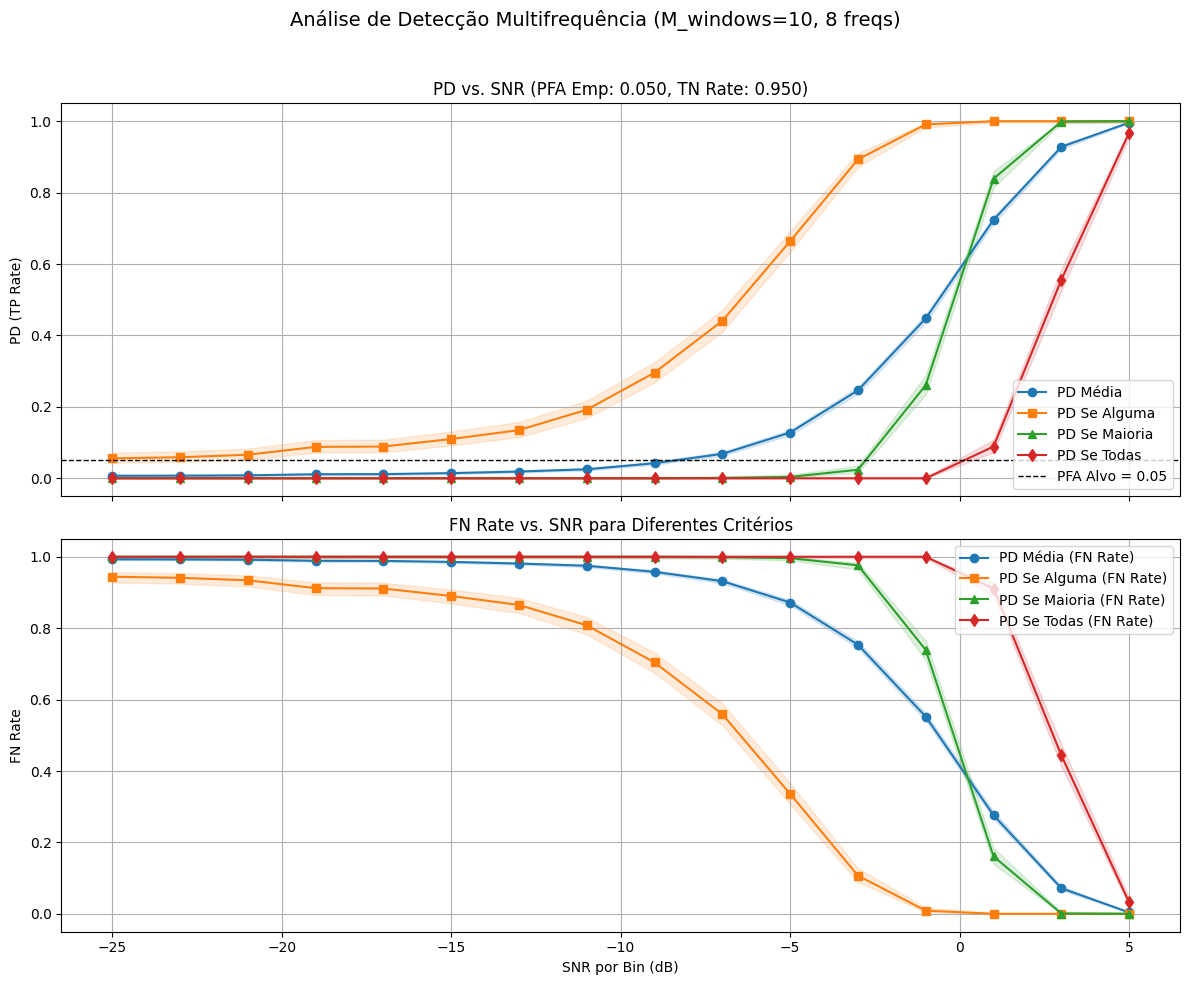

Simulação com análise de FN concluída.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, scoreatpercentile
import time

# --- Funções Auxiliares (msc_fft_py e wilson_score_interval_py da resposta anterior) ---
def msc_fft_py(Y_input, M_win):
    if Y_input.shape[1] == 0 or M_win == 0: return np.zeros(Y_input.shape[0])
    current_M_win = min(M_win, Y_input.shape[1])
    if current_M_win == 0: return np.zeros(Y_input.shape[0])
    if current_M_win == 1: return np.ones(Y_input.shape[0])
    Y_to_use = Y_input[:, :current_M_win]
    numerator = np.abs(np.sum(Y_to_use, axis=1))**2
    denominator = current_M_win * np.sum(np.abs(Y_to_use)**2, axis=1)
    msc = np.zeros_like(numerator, dtype=float)
    valid_den = denominator != 0
    msc[valid_den] = numerator[valid_den] / denominator[valid_den]
    msc[np.isnan(msc)] = 0; msc[np.isinf(msc)] = 0
    return msc

def wilson_score_interval_py(k, n, confidence_level=0.95):
    if n == 0: return np.nan, (np.nan, np.nan)
    alpha = 1 - confidence_level; z = norm.ppf(1 - alpha / 2)
    phat = k / n
    term1 = phat + (z**2) / (2 * n)
    term2 = z * np.sqrt((phat * (1 - phat) / n) + (z**2) / (4 * n**2))
    denominator = 1 + (z**2) / n
    pci_l = max(0, (term1 - term2) / denominator)
    pci_u = min(1, (term1 + term2) / denominator)
    return phat, (pci_l, pci_u)

# --- Parâmetros da Simulação (mesmos da resposta anterior) ---
FS = 1000; NFFT_msc = 512; M_windows = 10
signal_frequencies = np.array([82, 84, 86, 88, 90, 92, 94, 96])
fp_frequencies = np.array([82, 84, 86, 88, 90, 92, 94, 96])
num_signal_freqs = len(signal_frequencies)
num_fp_freqs = len(fp_frequencies)
target_pfa = 0.05
N_trials_H0 = 10000
N_master_trials_H1 = 1000
snr_db_per_bin_range = np.arange(-25, 5 + 1, 2)

total_samples_msc = NFFT_msc * M_windows
t_msc_segment = np.arange(NFFT_msc) / FS
hanning_win_msc = np.hanning(NFFT_msc)

fp_bin_indices_py = np.zeros(num_fp_freqs, dtype=int)
fp_frequencies_adj = np.zeros(num_fp_freqs)
for i, f_val in enumerate(fp_frequencies):
    bin_idx_ideal = int(round(f_val * NFFT_msc / FS))
    fp_frequencies_adj[i] = bin_idx_ideal * FS / NFFT_msc
    fp_bin_indices_py[i] = bin_idx_ideal
signal_bin_indices_py = np.zeros(num_signal_freqs, dtype=int)
signal_frequencies_adj = np.zeros(num_signal_freqs)
for i, f_val in enumerate(signal_frequencies):
    bin_idx_ideal = int(round(f_val * NFFT_msc / FS))
    signal_frequencies_adj[i] = bin_idx_ideal * FS / NFFT_msc
    signal_bin_indices_py[i] = bin_idx_ideal
print(f"Frequências de FP ajustadas: {fp_frequencies_adj}")
print(f"Frequências de Sinal ajustadas: {signal_frequencies_adj}")

# --- Parte 1: Determinação do Limiar e PFA/TN Empírica (H0) ---
print(f'Calculando limiar da MSC e PFA/TN empírica (H0)...')
start_time_h0 = time.time()
max_msc_values_H0_at_fp_freqs = np.zeros(N_trials_H0)
sigma_n_sq_time = 1.0
for i in range(N_trials_H0):
    noise_all_windows_H0 = np.sqrt(sigma_n_sq_time) * np.random.randn(total_samples_msc)
    Y_fft_H0_all_windows = np.zeros((NFFT_msc // 2 + 1, M_windows), dtype=complex)
    for k in range(M_windows):
        start_idx = k * NFFT_msc; end_idx = (k + 1) * NFFT_msc
        window_data = noise_all_windows_H0[start_idx:end_idx]
        Y_fft_H0_all_windows[:, k] = np.fft.rfft(window_data * hanning_win_msc)
    msc_spectrum_H0 = msc_fft_py(Y_fft_H0_all_windows, M_windows)
    valid_indices_h0 = fp_bin_indices_py[(fp_bin_indices_py >= 0) & (fp_bin_indices_py < len(msc_spectrum_H0))]
    if msc_spectrum_H0 is not None and len(valid_indices_h0) == num_fp_freqs:
        msc_at_fp_bins = msc_spectrum_H0[valid_indices_h0]
        max_msc_values_H0_at_fp_freqs[i] = np.max(msc_at_fp_bins)
    else: max_msc_values_H0_at_fp_freqs[i] = np.nan
    if (i + 1) % (N_trials_H0 // 10) == 0 and N_trials_H0 >=10: print(f'  H0 trial {i+1}/{N_trials_H0}')
valid_msc_H0 = max_msc_values_H0_at_fp_freqs[~np.isnan(max_msc_values_H0_at_fp_freqs)]
if len(valid_msc_H0) == 0: raise ValueError("Não foi possível calcular valores de MSC para H0.")
threshold_msc = scoreatpercentile(valid_msc_H0, (1 - target_pfa) * 100)
num_false_positives_H0 = np.sum(valid_msc_H0 > threshold_msc)
pfa_empirical_H0 = num_false_positives_H0 / len(valid_msc_H0)
tn_rate_H0 = 1 - pfa_empirical_H0
end_time_h0 = time.time()
print(f'Limiar MSC: {threshold_msc:.4f} (Tempo H0: {end_time_h0 - start_time_h0:.2f}s)')
print(f'PFA Empírica (H0): {pfa_empirical_H0:.4f} (FP Rate)')
print(f'Taxa de Verdadeiro Negativo (H0 - Especificidade): {tn_rate_H0:.4f}')

# --- Parte 2: Cálculo da PD e FN Rate para diferentes Critérios (H1) ---
pd_crit_list = [] 
fn_crit_list = []
criteria_names = ['PD Média', 'PD Se Alguma', 'PD Se Maioria', 'PD Se Todas']
num_criteria = len(criteria_names)
for name in criteria_names:
    pd_crit_list.append({'name': name, 'values': np.zeros(len(snr_db_per_bin_range)), 'ic_lower': np.zeros(len(snr_db_per_bin_range)), 'ic_upper': np.zeros(len(snr_db_per_bin_range))})
    fn_crit_list.append({'name': f'{name} (FN Rate)', 'values': np.zeros(len(snr_db_per_bin_range)), 'ic_lower': np.zeros(len(snr_db_per_bin_range)), 'ic_upper': np.zeros(len(snr_db_per_bin_range))})
P_n_bin_expected = (2.0 / NFFT_msc) * sigma_n_sq_time

print('Calculando PD e FN Rate para diferentes SNRs e Critérios (H1)...')
start_time_h1_total = time.time()
for snr_idx, current_snr_db in enumerate(snr_db_per_bin_range):
    start_time_snr_loop = time.time()
    current_snr_linear = 10**(current_snr_db / 10)
    P_s_bin_target = current_snr_linear * P_n_bin_expected
    A_signal = np.sqrt(2 * P_s_bin_target)
    detections_count_crit = np.zeros(num_criteria, dtype=int)
    for master_trial in range(N_master_trials_H1):
        individual_detections_this_master_trial = np.zeros(num_signal_freqs, dtype=int)
        for sig_f_idx in range(num_signal_freqs):
            current_f_signal = signal_frequencies_adj[sig_f_idx]
            current_signal_actual_bin = signal_bin_indices_py[sig_f_idx]
            s_t_single_window = A_signal * np.sin(2 * np.pi * current_f_signal * t_msc_segment)
            s_t_all_windows = np.tile(s_t_single_window, M_windows)
            n_t_all_windows = np.sqrt(sigma_n_sq_time) * np.random.randn(total_samples_msc)
            x_t_all_windows = s_t_all_windows + n_t_all_windows
            Y_fft_H1_all_windows = np.zeros((NFFT_msc // 2 + 1, M_windows), dtype=complex)
            for k_win in range(M_windows):
                start_idx = k_win * NFFT_msc; end_idx = (k_win + 1) * NFFT_msc
                window_data = x_t_all_windows[start_idx:end_idx]
                Y_fft_H1_all_windows[:, k_win] = np.fft.rfft(window_data * hanning_win_msc)
            msc_spectrum_H1 = msc_fft_py(Y_fft_H1_all_windows, M_windows)
            current_msc_at_signal_bin = np.nan
            if msc_spectrum_H1 is not None and len(msc_spectrum_H1) > current_signal_actual_bin and current_signal_actual_bin >= 0:
                 current_msc_at_signal_bin = msc_spectrum_H1[current_signal_actual_bin]
            if not np.isnan(current_msc_at_signal_bin) and current_msc_at_signal_bin > threshold_msc:
                individual_detections_this_master_trial[sig_f_idx] = 1
        num_detected_in_master_trial = np.sum(individual_detections_this_master_trial)
        detections_count_crit[0] += num_detected_in_master_trial
        if num_detected_in_master_trial > 0: detections_count_crit[1] += 1
        if num_detected_in_master_trial > (num_signal_freqs / 2): detections_count_crit[2] += 1
        if num_detected_in_master_trial == num_signal_freqs: detections_count_crit[3] += 1
            
    total_individual_detection_opportunities = N_master_trials_H1 * num_signal_freqs
    pd_val1, (pci_l1, pci_u1) = wilson_score_interval_py(detections_count_crit[0], total_individual_detection_opportunities)
    pd_crit_list[0]['values'][snr_idx] = pd_val1
    pd_crit_list[0]['ic_lower'][snr_idx] = pci_l1; pd_crit_list[0]['ic_upper'][snr_idx] = pci_u1
    fn_crit_list[0]['values'][snr_idx] = 1 - pd_val1
    fn_crit_list[0]['ic_lower'][snr_idx] = 1 - pci_u1; fn_crit_list[0]['ic_upper'][snr_idx] = 1 - pci_l1

    for c_idx in range(1, num_criteria):
        pd_val, (pci_l, pci_u) = wilson_score_interval_py(detections_count_crit[c_idx], N_master_trials_H1)
        pd_crit_list[c_idx]['values'][snr_idx] = pd_val
        pd_crit_list[c_idx]['ic_lower'][snr_idx] = pci_l; pd_crit_list[c_idx]['ic_upper'][snr_idx] = pci_u
        fn_crit_list[c_idx]['values'][snr_idx] = 1 - pd_val
        fn_crit_list[c_idx]['ic_lower'][snr_idx] = 1 - pci_u; fn_crit_list[c_idx]['ic_upper'][snr_idx] = 1 - pci_l
    
    print(f'  SNR={current_snr_db:.1f}dB: PD_M={pd_crit_list[0]["values"][snr_idx]:.3f}, PD_Any={pd_crit_list[1]["values"][snr_idx]:.3f}, PD_Maj={pd_crit_list[2]["values"][snr_idx]:.3f}, PD_All={pd_crit_list[3]["values"][snr_idx]:.3f}')
end_time_h1_total = time.time()
print(f'Tempo total H1: {end_time_h1_total - start_time_h1_total:.2f}s')

# --- Parte 3: Plotagem ---
fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
plot_styles = ['-o', '-s', '-^', '-d']
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

# Gráfico 1: PD (TP Rate) vs SNR
for c_idx in range(num_criteria):
    axs[0].plot(snr_db_per_bin_range, pd_crit_list[c_idx]['values'], plot_styles[c_idx],
                color=colors[c_idx % len(colors)], linewidth=1.5, label=pd_crit_list[c_idx]['name'])
    axs[0].fill_between(snr_db_per_bin_range, pd_crit_list[c_idx]['ic_lower'], pd_crit_list[c_idx]['ic_upper'],
                        color=colors[c_idx % len(colors)], alpha=0.15)
axs[0].axhline(target_pfa, color='k', linestyle='--', linewidth=1, label=f'PFA Alvo = {target_pfa:.2f}')
axs[0].set_ylabel('PD (TP Rate)')
axs[0].set_title(f'PD vs. SNR (PFA Emp: {pfa_empirical_H0:.3f}, TN Rate: {tn_rate_H0:.3f})')
axs[0].legend(loc='lower right')
axs[0].grid(True)
axs[0].set_ylim([-0.05, 1.05])

# Gráfico 2: FN Rate vs SNR
for c_idx in range(num_criteria):
    axs[1].plot(snr_db_per_bin_range, fn_crit_list[c_idx]['values'], plot_styles[c_idx],
                color=colors[c_idx % len(colors)], linewidth=1.5, label=fn_crit_list[c_idx]['name']) # Usa cores PD
    axs[1].fill_between(snr_db_per_bin_range, fn_crit_list[c_idx]['ic_lower'], fn_crit_list[c_idx]['ic_upper'],
                        color=colors[c_idx % len(colors)], alpha=0.15)
axs[1].set_xlabel('SNR por Bin (dB)')
axs[1].set_ylabel('FN Rate')
axs[1].set_title('FN Rate vs. SNR para Diferentes Critérios')
axs[1].legend(loc='upper right')
axs[1].grid(True)
axs[1].set_ylim([-0.05, 1.05])

fig.suptitle(f'Análise de Detecção Multifrequência (M_windows={M_windows}, {num_signal_freqs} freqs)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajustar para suptitle
plt.show()

print('Simulação com análise de FN concluída.')

Signal Freqs Adjusted: [82.03125  83.984375 85.9375   87.890625 89.84375  91.796875 93.75
 95.703125]
Noise (H1) Freqs Adjusted: [ 41.015625  50.78125   60.546875  70.3125   101.5625   111.328125
 121.09375  130.859375]
FP Ref (H0) Freqs Adjusted: [ 41.015625  50.78125   60.546875  70.3125   101.5625   111.328125
 121.09375  130.859375]

--- Processing Metric: MSC ---
Calculating threshold for MSC (H0)...
  H0 trial 500/5000 for MSC
  H0 trial 1000/5000 for MSC
  H0 trial 1500/5000 for MSC
  H0 trial 2000/5000 for MSC
  H0 trial 2500/5000 for MSC
  H0 trial 3000/5000 for MSC
  H0 trial 3500/5000 for MSC
  H0 trial 4000/5000 for MSC
  H0 trial 4500/5000 for MSC
  H0 trial 5000/5000 for MSC
Threshold MSC: 0.4257 (Time H0: 2.36s)
PFA Emp. Global (H0) for MSC: 0.0500
TN Rate Global (H0) for MSC: 0.9500
Calculating PD/FN & FP_H1/TN_H1 for MSC...
  SNR=-25.0dB (MSC): PD_M=0.007, FP_H1_M=0.0050
  SNR=-20.0dB (MSC): PD_M=0.007, FP_H1_M=0.0055
  SNR=-15.0dB (MSC): PD_M=0.012, FP_H1_M=0.0065
  S

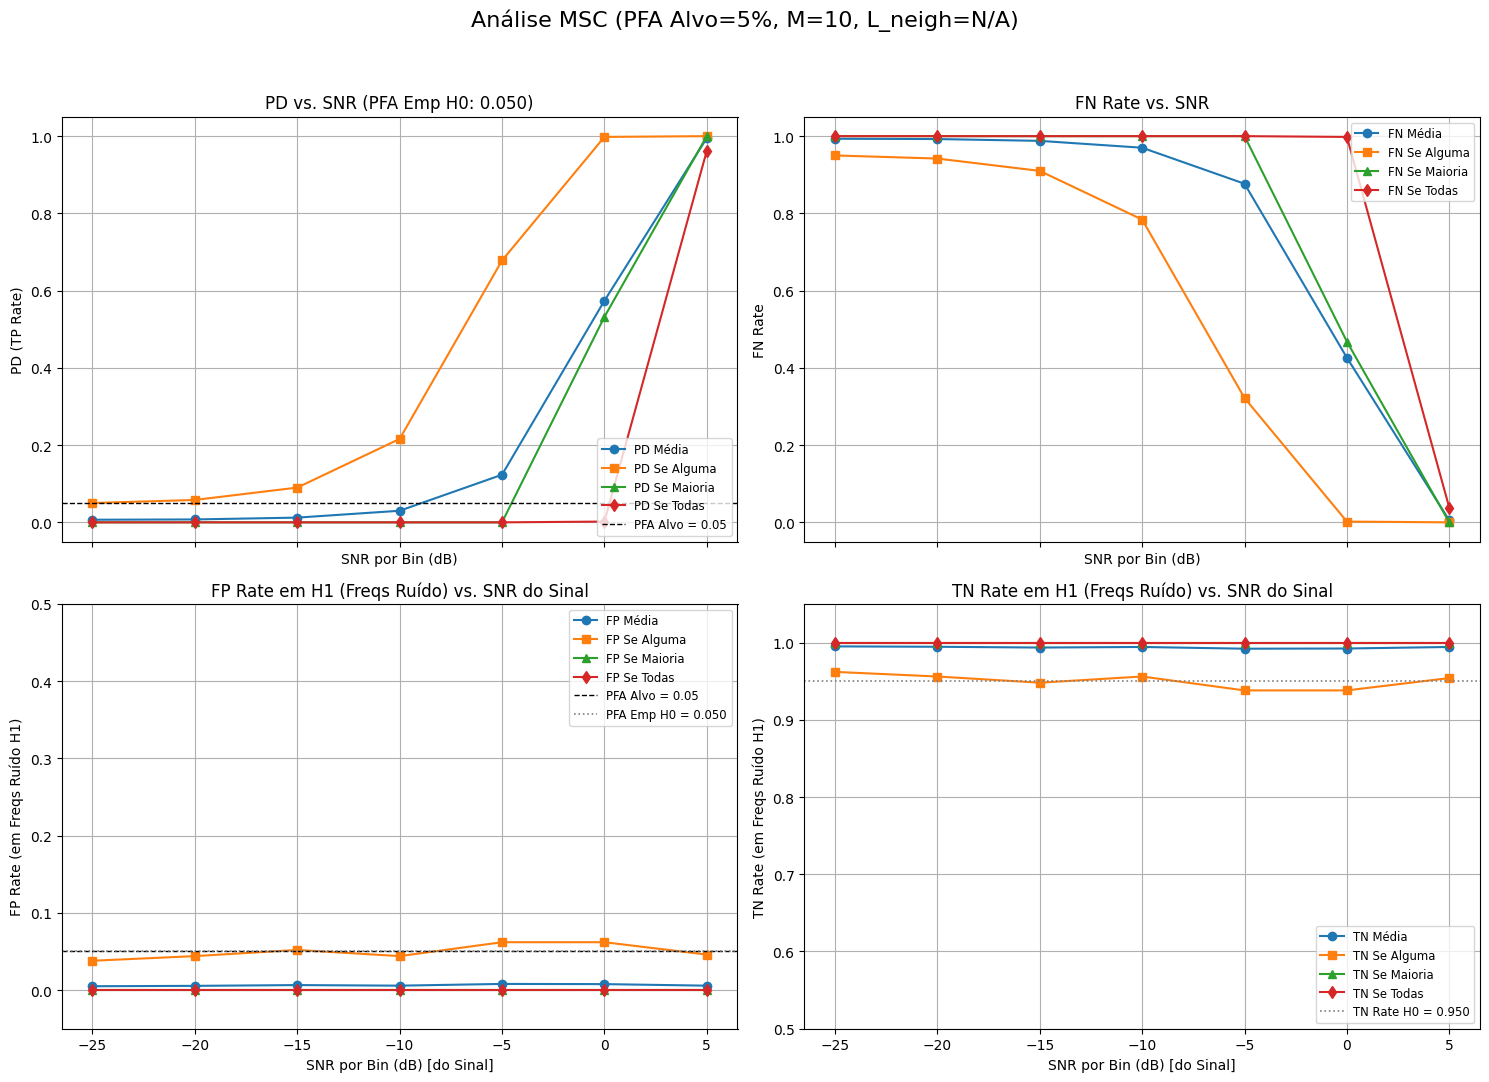


--- Processing Metric: CSM ---
Calculating threshold for CSM (H0)...
  H0 trial 500/5000 for CSM
  H0 trial 1000/5000 for CSM
  H0 trial 1500/5000 for CSM
  H0 trial 2000/5000 for CSM
  H0 trial 2500/5000 for CSM
  H0 trial 3000/5000 for CSM
  H0 trial 3500/5000 for CSM
  H0 trial 4000/5000 for CSM
  H0 trial 4500/5000 for CSM
  H0 trial 5000/5000 for CSM
Threshold CSM: 0.4599 (Time H0: 3.30s)
PFA Emp. Global (H0) for CSM: 0.0500
TN Rate Global (H0) for CSM: 0.9500
Calculating PD/FN & FP_H1/TN_H1 for CSM...
  SNR=-25.0dB (CSM): PD_M=0.008, FP_H1_M=0.0047
  SNR=-20.0dB (CSM): PD_M=0.006, FP_H1_M=0.0065
  SNR=-15.0dB (CSM): PD_M=0.009, FP_H1_M=0.0065
  SNR=-10.0dB (CSM): PD_M=0.028, FP_H1_M=0.0097
  SNR=-5.0dB (CSM): PD_M=0.120, FP_H1_M=0.0070
  SNR=0.0dB (CSM): PD_M=0.460, FP_H1_M=0.0065
  SNR=5.0dB (CSM): PD_M=0.975, FP_H1_M=0.0065
Time total H1 for CSM: 15.19s


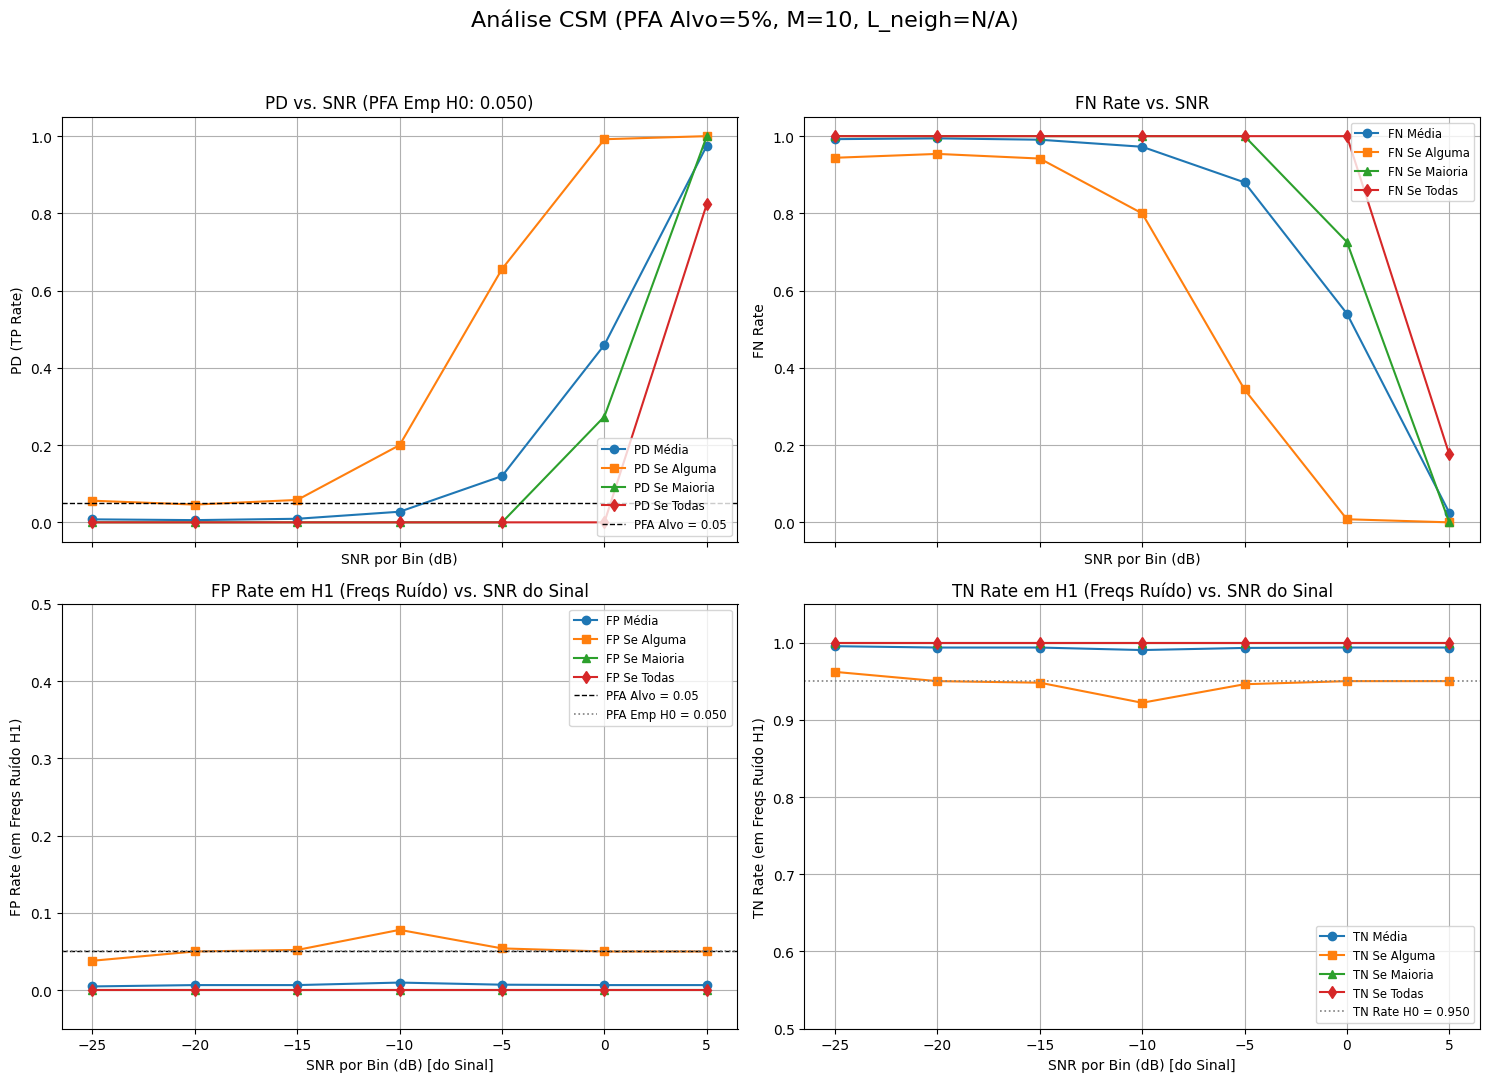


--- Processing Metric: LFT ---
Calculating threshold for LFT (H0)...
  H0 trial 500/5000 for LFT
  H0 trial 1000/5000 for LFT
  H0 trial 1500/5000 for LFT
  H0 trial 2000/5000 for LFT
  H0 trial 2500/5000 for LFT
  H0 trial 3000/5000 for LFT
  H0 trial 3500/5000 for LFT
  H0 trial 4000/5000 for LFT
  H0 trial 4500/5000 for LFT
  H0 trial 5000/5000 for LFT
Threshold LFT: 1.9265 (Time H0: 29.22s)
PFA Emp. Global (H0) for LFT: 0.0500
TN Rate Global (H0) for LFT: 0.9500
Calculating PD/FN & FP_H1/TN_H1 for LFT...
  SNR=-25.0dB (LFT): PD_M=0.005, FP_H1_M=0.0055
  SNR=-20.0dB (LFT): PD_M=0.005, FP_H1_M=0.0053
  SNR=-15.0dB (LFT): PD_M=0.008, FP_H1_M=0.0067
  SNR=-10.0dB (LFT): PD_M=0.009, FP_H1_M=0.0060
  SNR=-5.0dB (LFT): PD_M=0.034, FP_H1_M=0.0063
  SNR=0.0dB (LFT): PD_M=0.183, FP_H1_M=0.0050
  SNR=5.0dB (LFT): PD_M=0.870, FP_H1_M=0.0075
Time total H1 for LFT: 211.08s


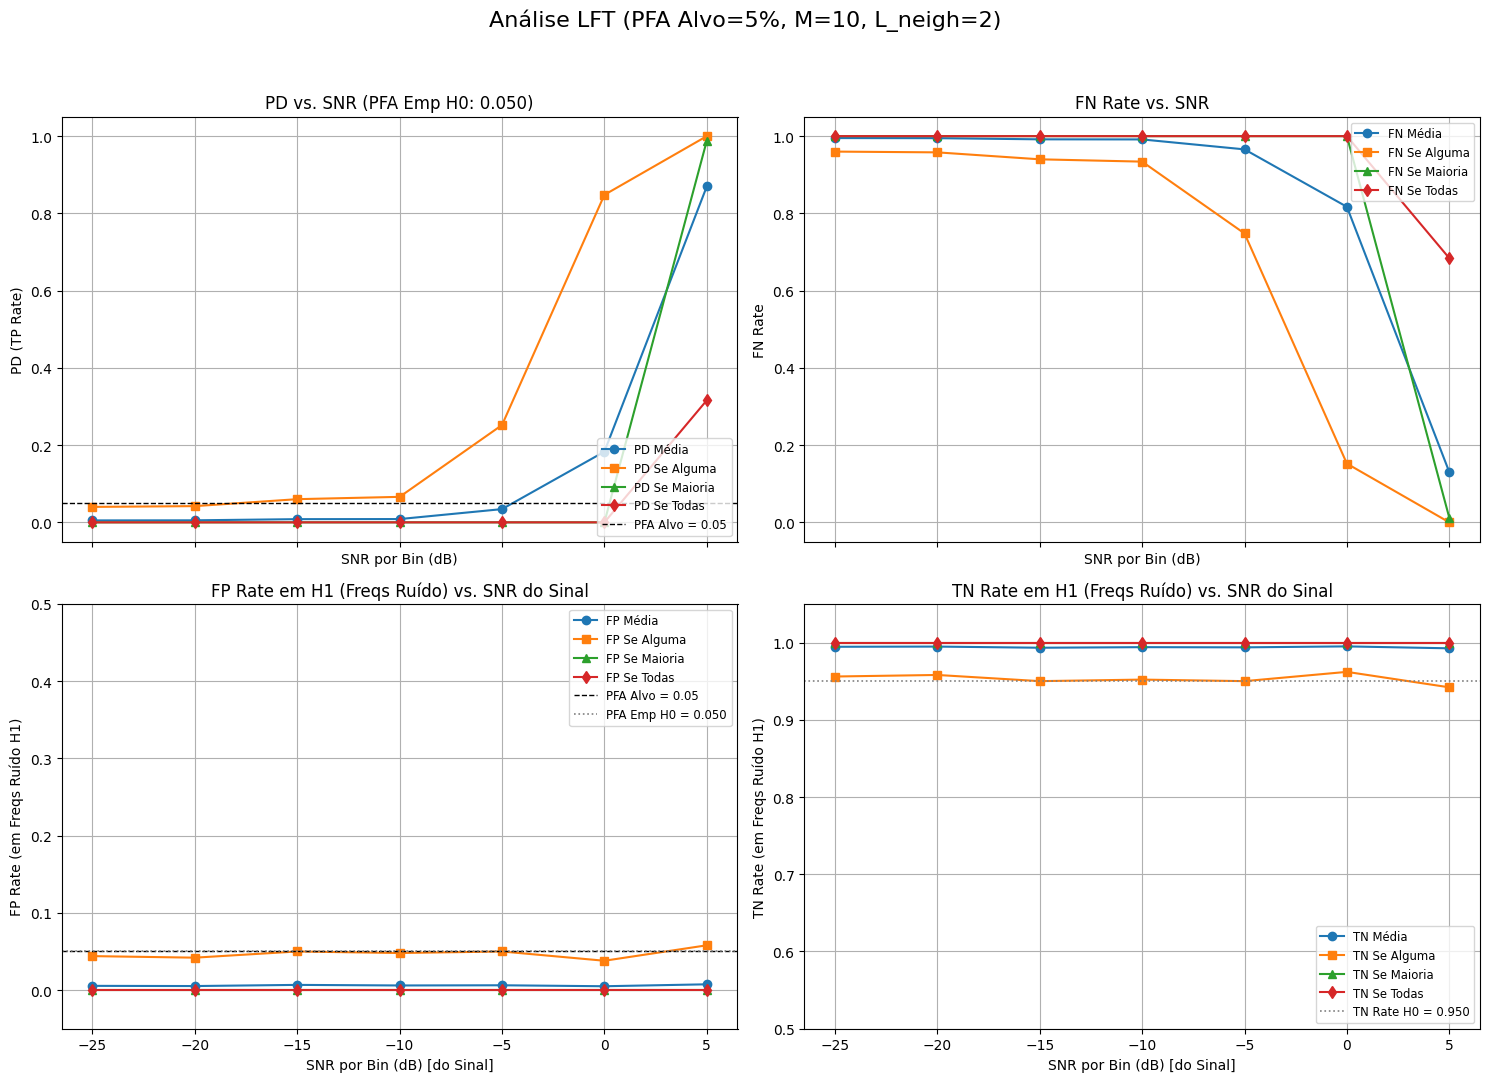

Simulação com múltiplas métricas concluída.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, scoreatpercentile
import time

# --- Helper Functions (msc_fft_py, wilson_score_interval_py from previous responses) ---
def msc_fft_py(Y_input, M_win):
    # Y_input is (num_bins, M_win)
    if Y_input.shape[1] == 0 or M_win == 0: return np.zeros(Y_input.shape[0])
    current_M_win = min(M_win, Y_input.shape[1])
    if current_M_win == 0: return np.zeros(Y_input.shape[0])
    if current_M_win == 1: return np.ones(Y_input.shape[0]) # Or handle M=1 as needed

    Y_to_use = Y_input[:, :current_M_win]
    numerator = np.abs(np.sum(Y_to_use, axis=1))**2
    denominator = current_M_win * np.sum(np.abs(Y_to_use)**2, axis=1)
    
    msc = np.zeros_like(numerator, dtype=float)
    valid_den_mask = denominator != 0
    msc[valid_den_mask] = numerator[valid_den_mask] / denominator[valid_den_mask]
    
    msc[np.isnan(msc)] = 0
    msc[np.isinf(msc)] = 0 # Or a large number, or based on non-inf max
    return msc

def csm_fft_py(Y_fft_all_windows, M_win_dummy): # M_win not directly used if Y_fft already epoched
    # Y_fft_all_windows is (num_bins, M_win)
    if Y_fft_all_windows.shape[1] == 0:
        return np.zeros(Y_fft_all_windows.shape[0])
    phases = np.angle(Y_fft_all_windows)
    mean_cos = np.mean(np.cos(phases), axis=1)
    mean_sin = np.mean(np.sin(phases), axis=1)
    csm_spectrum = mean_cos**2 + mean_sin**2
    csm_spectrum[np.isnan(csm_spectrum)] = 0
    return csm_spectrum

def lft_fft_py(Y_fft_all_windows, M_win_dummy, L_neighbors):
    # Y_fft_all_windows is (num_bins, M_win)
    if Y_fft_all_windows.shape[1] == 0:
        return np.zeros(Y_fft_all_windows.shape[0])
        
    power_spectrum_per_window = np.abs(Y_fft_all_windows)**2
    avg_power_spectrum = np.mean(power_spectrum_per_window, axis=1) # Power(f_0)
    num_bins = len(avg_power_spectrum)
    lft_spectrum = np.zeros(num_bins, dtype=float)

    for f_idx in range(num_bins):
        signal_power = avg_power_spectrum[f_idx]
        
        # Define neighbor indices, excluding f_idx itself
        lower_indices = np.arange(max(0, f_idx - L_neighbors), f_idx)
        upper_indices = np.arange(f_idx + 1, min(num_bins, f_idx + L_neighbors + 1))
        all_neighbor_indices = np.concatenate((lower_indices, upper_indices)).astype(int)
        all_neighbor_indices = np.unique(all_neighbor_indices) # Ensure unique and sorted
        
        if len(all_neighbor_indices) < L_neighbors : # Need at least L_neighbors total for somewhat stable estimate
            mean_noise_power = 1e-12 # Avoid division by zero, effectively high LFT
        else:
            noise_power_bins = avg_power_spectrum[all_neighbor_indices]
            mean_noise_power = np.mean(noise_power_bins)

        if mean_noise_power < 1e-12: # Threshold to prevent division by very small numbers
            lft_spectrum[f_idx] = signal_power / 1e-12
        else:
            lft_spectrum[f_idx] = signal_power / mean_noise_power
            
    lft_spectrum[np.isnan(lft_spectrum)] = 0
    non_inf_max = np.max(lft_spectrum[~np.isinf(lft_spectrum)], initial=1e6) # Cap inf values
    lft_spectrum[np.isinf(lft_spectrum)] = non_inf_max if non_inf_max > 0 else 1e6

    return lft_spectrum


def wilson_score_interval_py(k, n, confidence_level=0.95):
    if n == 0 or np.isnan(n) or np.isnan(k) or n < k: return np.nan, (np.nan, np.nan) # n < k is invalid
    k = np.nan_to_num(float(k)) 
    n = float(n)
    alpha = 1 - confidence_level; z = norm.ppf(1 - alpha / 2)
    phat = k / n
    term1_num = phat + (z**2) / (2 * n)
    term2_num = z * np.sqrt((phat * (1 - phat) / n) + (z**2) / (4 * n**2))
    denominator = 1 + (z**2) / n
    pci_l = max(0, (term1_num - term2_num) / denominator)
    pci_u = min(1, (term1_num + term2_num) / denominator)
    return phat, (pci_l, pci_u)

def adjust_freqs_get_bins_py(nominal_freqs, NFFT_val, FS_rate):
    adj_freqs = np.zeros_like(nominal_freqs, dtype=float)
    bin_indices = np.zeros_like(nominal_freqs, dtype=int)
    for i, f_val in enumerate(nominal_freqs):
        bin_idx_ideal = int(round(f_val * NFFT_val / FS_rate))
        adj_freqs[i] = bin_idx_ideal * FS_rate / NFFT_val
        bin_indices[i] = bin_idx_ideal 
    return adj_freqs, bin_indices

# --- Simulation Parameters ---
FS = 1000; NFFT = 512; M_windows = 10
signal_frequencies_nominal = np.array([82, 84, 86, 88, 90, 92, 94, 96])
noise_only_frequencies_nominal = np.array([41, 51, 61, 71, 101, 111, 121, 131])
fp_reference_frequencies_nominal = noise_only_frequencies_nominal.copy()

num_signal_freqs = len(signal_frequencies_nominal)
num_noise_only_freqs = len(noise_only_frequencies_nominal)
num_fp_ref_freqs = len(fp_reference_frequencies_nominal)

target_pfa = 0.05
N_trials_H0 = 5000 # Reduced for demo
N_master_trials_H1 = 500 # Reduced for demo
snr_db_per_bin_range = np.arange(-25, 5 + 1, 5) # Coarser for demo

L_neighbors_lft = 2 # For LFT

total_samples = NFFT * M_windows
t_segment = np.arange(NFFT) / FS
hanning_win = np.hanning(NFFT)

signal_frequencies_adj, signal_bin_indices_py = adjust_freqs_get_bins_py(signal_frequencies_nominal, NFFT, FS)
noise_only_frequencies_adj, noise_only_bin_indices_py = adjust_freqs_get_bins_py(noise_only_frequencies_nominal, NFFT, FS)
fp_reference_frequencies_adj, fp_ref_bin_indices_py = adjust_freqs_get_bins_py(fp_reference_frequencies_nominal, NFFT, FS)

print(f"Signal Freqs Adjusted: {signal_frequencies_adj}")
print(f"Noise (H1) Freqs Adjusted: {noise_only_frequencies_adj}")
print(f"FP Ref (H0) Freqs Adjusted: {fp_reference_frequencies_adj}")

metrics_to_run = ['MSC', 'CSM', 'LFT']
sigma_n_sq_time = 1.0
P_n_bin_expected = (2.0 / NFFT) * sigma_n_sq_time # For rfft, one-sided

for metric_name in metrics_to_run:
    print(f"\n--- Processing Metric: {metric_name} ---")

    # --- Part 1: H0 - Threshold Determination ---
    print(f'Calculating threshold for {metric_name} (H0)...')
    start_time_h0 = time.time()
    max_metric_values_H0 = np.zeros(N_trials_H0)

    for i in range(N_trials_H0):
        noise_all_windows_H0 = np.sqrt(sigma_n_sq_time) * np.random.randn(total_samples)
        Y_fft_H0_all_windows = np.zeros((NFFT // 2 + 1, M_windows), dtype=complex)
        for k_win in range(M_windows):
            start_idx = k_win * NFFT; end_idx = (k_win + 1) * NFFT
            window_data = noise_all_windows_H0[start_idx:end_idx]
            Y_fft_H0_all_windows[:, k_win] = np.fft.rfft(window_data * hanning_win)
        
        metric_spectrum_H0 = None
        if metric_name == 'MSC':
            metric_spectrum_H0 = msc_fft_py(Y_fft_H0_all_windows, M_windows)
        elif metric_name == 'CSM':
            metric_spectrum_H0 = csm_fft_py(Y_fft_H0_all_windows, M_windows)
        elif metric_name == 'LFT':
            metric_spectrum_H0 = lft_fft_py(Y_fft_H0_all_windows, M_windows, L_neighbors_lft)

        valid_indices_h0 = fp_ref_bin_indices_py[(fp_ref_bin_indices_py >= 0) & (fp_ref_bin_indices_py < len(metric_spectrum_H0))]
        if metric_spectrum_H0 is not None and len(valid_indices_h0) == num_fp_ref_freqs:
            metric_at_fp_ref_bins = metric_spectrum_H0[valid_indices_h0]
            max_metric_values_H0[i] = np.max(metric_at_fp_ref_bins)
        else:
            max_metric_values_H0[i] = np.nan
        if (i + 1) % (N_trials_H0 // 10) == 0 and N_trials_H0 >=10: print(f'  H0 trial {i+1}/{N_trials_H0} for {metric_name}')
    
    valid_metric_H0 = max_metric_values_H0[~np.isnan(max_metric_values_H0)]
    if len(valid_metric_H0) == 0: raise ValueError(f"Could not calculate H0 metric values for {metric_name}.")
    
    threshold_metric = scoreatpercentile(valid_metric_H0, (1 - target_pfa) * 100)
    num_fp_global_H0 = np.sum(valid_metric_H0 > threshold_metric)
    pfa_empirical_global_H0_metric = num_fp_global_H0 / len(valid_metric_H0)
    tn_rate_global_H0_metric = 1 - pfa_empirical_global_H0_metric
    end_time_h0 = time.time()

    print(f'Threshold {metric_name}: {threshold_metric:.4f} (Time H0: {end_time_h0 - start_time_h0:.2f}s)')
    print(f'PFA Emp. Global (H0) for {metric_name}: {pfa_empirical_global_H0_metric:.4f}')
    print(f'TN Rate Global (H0) for {metric_name}: {tn_rate_global_H0_metric:.4f}')

    # --- Part 2: H1 - PD/FN (Signal) & FP/TN (Noise in H1) ---
    criteria_names = ['Média', 'Se Alguma', 'Se Maioria', 'Se Todas']
    num_criteria = len(criteria_names)
    results_H1_metric = {}
    for name in criteria_names:
        results_H1_metric[name] = {
            'PD': np.zeros(len(snr_db_per_bin_range)), 'PD_ic_lower': np.zeros(len(snr_db_per_bin_range)), 'PD_ic_upper': np.zeros(len(snr_db_per_bin_range)),
            'FN_Rate': np.zeros(len(snr_db_per_bin_range)), 'FN_ic_lower': np.zeros(len(snr_db_per_bin_range)), 'FN_ic_upper': np.zeros(len(snr_db_per_bin_range)),
            'FP_Rate_H1': np.zeros(len(snr_db_per_bin_range)), 'FP_H1_ic_lower': np.zeros(len(snr_db_per_bin_range)), 'FP_H1_ic_upper': np.zeros(len(snr_db_per_bin_range)),
            'TN_Rate_H1': np.zeros(len(snr_db_per_bin_range)), 'TN_H1_ic_lower': np.zeros(len(snr_db_per_bin_range)), 'TN_H1_ic_upper': np.zeros(len(snr_db_per_bin_range)),
        }
    
    print(f'Calculating PD/FN & FP_H1/TN_H1 for {metric_name}...')
    start_time_h1_total = time.time()
    for snr_idx, current_snr_db in enumerate(snr_db_per_bin_range):
        current_snr_linear = 10**(current_snr_db / 10)
        P_s_bin_target = current_snr_linear * P_n_bin_expected
        A_signal = np.sqrt(2 * P_s_bin_target) # For one-sided rfft power

        counts_PD_agg = np.zeros(num_criteria, dtype=int)
        counts_FP_H1_agg = np.zeros(num_criteria, dtype=int)

        for master_trial in range(N_master_trials_H1):
            n_t_all_windows_master = np.sqrt(sigma_n_sq_time) * np.random.randn(total_samples)
            
            Y_fft_noise_master_all_windows = np.zeros((NFFT // 2 + 1, M_windows), dtype=complex)
            for k_win in range(M_windows):
                start_idx = k_win * NFFT; end_idx = (k_win + 1) * NFFT
                window_data_noise = n_t_all_windows_master[start_idx:end_idx]
                Y_fft_noise_master_all_windows[:, k_win] = np.fft.rfft(window_data_noise * hanning_win)
            
            metric_spectrum_noise_master = None
            if metric_name == 'MSC':
                metric_spectrum_noise_master = msc_fft_py(Y_fft_noise_master_all_windows, M_windows)
            elif metric_name == 'CSM':
                metric_spectrum_noise_master = csm_fft_py(Y_fft_noise_master_all_windows, M_windows)
            elif metric_name == 'LFT':
                metric_spectrum_noise_master = lft_fft_py(Y_fft_noise_master_all_windows, M_windows, L_neighbors_lft)

            metric_at_noise_only_bins_master = metric_spectrum_noise_master[noise_only_bin_indices_py]
            fp_results_for_noise_bins_master = (metric_at_noise_only_bins_master > threshold_metric).astype(int)
            
            num_fp_in_noise_master_trial = np.sum(fp_results_for_noise_bins_master)
            counts_FP_H1_agg[0] += num_fp_in_noise_master_trial # Média
            if num_fp_in_noise_master_trial > 0: counts_FP_H1_agg[1] += 1 # Se Alguma
            if num_fp_in_noise_master_trial > (num_noise_only_freqs / 2): counts_FP_H1_agg[2] += 1 # Se Maioria
            if num_fp_in_noise_master_trial == num_noise_only_freqs: counts_FP_H1_agg[3] += 1 # Se Todas

            individual_signal_detections_this_master_trial_list = []
            for sig_f_idx in range(num_signal_freqs):
                current_f_signal_adj = signal_frequencies_adj[sig_f_idx]
                current_signal_actual_bin = signal_bin_indices_py[sig_f_idx]
                
                s_t_single_window = A_signal * np.sin(2 * np.pi * current_f_signal_adj * t_segment)
                s_t_all_windows = np.tile(s_t_single_window, M_windows)
                x_t_all_windows = s_t_all_windows + n_t_all_windows_master
                
                Y_fft_H1_all_windows = np.zeros((NFFT // 2 + 1, M_windows), dtype=complex)
                for k_win in range(M_windows):
                    start_idx = k_win * NFFT; end_idx = (k_win + 1) * NFFT
                    window_data = x_t_all_windows[start_idx:end_idx]
                    Y_fft_H1_all_windows[:, k_win] = np.fft.rfft(window_data * hanning_win)
                
                metric_spectrum_H1 = None
                if metric_name == 'MSC':
                    metric_spectrum_H1 = msc_fft_py(Y_fft_H1_all_windows, M_windows)
                elif metric_name == 'CSM':
                    metric_spectrum_H1 = csm_fft_py(Y_fft_H1_all_windows, M_windows)
                elif metric_name == 'LFT':
                    metric_spectrum_H1 = lft_fft_py(Y_fft_H1_all_windows, M_windows, L_neighbors_lft)
                
                current_metric_at_signal_bin = np.nan
                if metric_spectrum_H1 is not None and len(metric_spectrum_H1) > current_signal_actual_bin and current_signal_actual_bin >= 0:
                     current_metric_at_signal_bin = metric_spectrum_H1[current_signal_actual_bin]
                if not np.isnan(current_metric_at_signal_bin) and current_metric_at_signal_bin > threshold_metric:
                    individual_signal_detections_this_master_trial_list.append(1)
                else:
                    individual_signal_detections_this_master_trial_list.append(0)
            
            num_detected_signals_in_master_trial = np.sum(individual_signal_detections_this_master_trial_list)
            counts_PD_agg[0] += num_detected_signals_in_master_trial
            if num_detected_signals_in_master_trial > 0: counts_PD_agg[1] += 1
            if num_detected_signals_in_master_trial > (num_signal_freqs / 2): counts_PD_agg[2] += 1
            if num_detected_signals_in_master_trial == num_signal_freqs: counts_PD_agg[3] += 1
            
        n_PD_denominators = [N_master_trials_H1 * num_signal_freqs, N_master_trials_H1, N_master_trials_H1, N_master_trials_H1]
        n_FP_H1_denominators = [N_master_trials_H1 * num_noise_only_freqs, N_master_trials_H1, N_master_trials_H1, N_master_trials_H1]

        for c_idx, crit_name in enumerate(criteria_names):
            pd_val, (pci_l, pci_u) = wilson_score_interval_py(counts_PD_agg[c_idx], n_PD_denominators[c_idx])
            results_H1_metric[crit_name]['PD'][snr_idx] = pd_val
            results_H1_metric[crit_name]['PD_ic_lower'][snr_idx] = pci_l; results_H1_metric[crit_name]['PD_ic_upper'][snr_idx] = pci_u
            results_H1_metric[crit_name]['FN_Rate'][snr_idx] = 1 - pd_val if not np.isnan(pd_val) else np.nan
            results_H1_metric[crit_name]['FN_ic_lower'][snr_idx] = 1 - pci_u if not np.isnan(pci_u) else np.nan
            results_H1_metric[crit_name]['FN_ic_upper'][snr_idx] = 1 - pci_l if not np.isnan(pci_l) else np.nan

            fp_val, (fp_l, fp_u) = wilson_score_interval_py(counts_FP_H1_agg[c_idx], n_FP_H1_denominators[c_idx])
            results_H1_metric[crit_name]['FP_Rate_H1'][snr_idx] = fp_val
            results_H1_metric[crit_name]['FP_H1_ic_lower'][snr_idx] = fp_l; results_H1_metric[crit_name]['FP_H1_ic_upper'][snr_idx] = fp_u
            results_H1_metric[crit_name]['TN_Rate_H1'][snr_idx] = 1 - fp_val if not np.isnan(fp_val) else np.nan
            results_H1_metric[crit_name]['TN_H1_ic_lower'][snr_idx] = 1 - fp_u if not np.isnan(fp_u) else np.nan
            results_H1_metric[crit_name]['TN_H1_ic_upper'][snr_idx] = 1 - fp_l if not np.isnan(fp_l) else np.nan
        
        print(f'  SNR={current_snr_db:.1f}dB ({metric_name}): PD_M={results_H1_metric["Média"]["PD"][snr_idx]:.3f}, FP_H1_M={results_H1_metric["Média"]["FP_Rate_H1"][snr_idx]:.4f}')
    end_time_h1_total = time.time()
    print(f'Time total H1 for {metric_name}: {end_time_h1_total - start_time_h1_total:.2f}s')

    # --- Part 3: Plotting ---
    fig, axs = plt.subplots(2, 2, figsize=(15, 11), sharex=True)
    fig.suptitle(f'Análise {metric_name} (PFA Alvo={target_pfa*100:.0f}%, M={M_windows}, L_neigh={L_neighbors_lft if metric_name=="LFT" else "N/A"})', fontsize=16)
    plot_styles = ['-o', '-s', '-^', '-d']
    prop_cycle = plt.rcParams['axes.prop_cycle']
    colors = prop_cycle.by_key()['color']

    ax_map = {'PD': axs[0,0], 'FN_Rate': axs[0,1], 'FP_Rate_H1': axs[1,0], 'TN_Rate_H1': axs[1,1]}
    y_labels = {'PD': 'PD (TP Rate)', 'FN_Rate': 'FN Rate', 'FP_Rate_H1': 'FP Rate (em Freqs Ruído H1)', 'TN_Rate_H1': 'TN Rate (em Freqs Ruído H1)'}
    plot_titles = {
        'PD': f'PD vs. SNR (PFA Emp H0: {pfa_empirical_global_H0_metric:.3f})',
        'FN_Rate': 'FN Rate vs. SNR',
        'FP_Rate_H1': 'FP Rate em H1 (Freqs Ruído) vs. SNR do Sinal',
        'TN_Rate_H1': 'TN Rate em H1 (Freqs Ruído) vs. SNR do Sinal'
    }
    y_lims = {'PD': [-0.05, 1.05], 'FN_Rate': [-0.05, 1.05], 'FP_Rate_H1': [-0.05, 0.5], 'TN_Rate_H1': [0.5, 1.05]}
    legend_locs = {'PD': 'lower right', 'FN_Rate': 'upper right', 'FP_Rate_H1': 'upper right', 'TN_Rate_H1': 'lower right'}

    for rate_type in ['PD', 'FN_Rate', 'FP_Rate_H1', 'TN_Rate_H1']:
        ax = ax_map[rate_type]
        for c_idx, crit_name in enumerate(criteria_names):
            label_prefix = f"{rate_type.split('_')[0]} " # PD, FN, FP, TN
            ax.plot(snr_db_per_bin_range, results_H1_metric[crit_name][rate_type], plot_styles[c_idx],
                    color=colors[c_idx % len(colors)], linewidth=1.5, label=f"{label_prefix}{crit_name}")
            # Optional: fill_between for CIs - can make plots very busy
            # ax.fill_between(snr_db_per_bin_range, results_H1_metric[crit_name][f'{rate_type}_ic_lower'], results_H1_metric[crit_name][f'{rate_type}_ic_upper'],
            #                 color=colors[c_idx % len(colors)], alpha=0.1)
        
        if rate_type == 'PD' or rate_type == 'FP_Rate_H1':
            ax.axhline(target_pfa, color='k', linestyle='--', linewidth=1, label=f'PFA Alvo = {target_pfa:.2f}')
        if rate_type == 'FP_Rate_H1':
            ax.axhline(pfa_empirical_global_H0_metric, color='grey', linestyle=':', linewidth=1.2, label=f'PFA Emp H0 = {pfa_empirical_global_H0_metric:.3f}')
        if rate_type == 'TN_Rate_H1':
            ax.axhline(tn_rate_global_H0_metric, color='grey', linestyle=':', linewidth=1.2, label=f'TN Rate H0 = {tn_rate_global_H0_metric:.3f}')

        ax.set_ylabel(y_labels[rate_type])
        ax.set_title(plot_titles[rate_type])
        ax.legend(loc=legend_locs[rate_type], fontsize='small')
        ax.grid(True)
        ax.set_ylim(y_lims[rate_type])
        if rate_type.startswith('FP') or rate_type.startswith('TN'):
             ax.set_xlabel('SNR por Bin (dB) [do Sinal]')
        else:
             ax.set_xlabel('SNR por Bin (dB)')

    plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust for suptitle
    plt.show()

print('Simulação com múltiplas métricas concluída.')

Signal Freqs Adjusted: [82.03125  83.984375 85.9375   87.890625 89.84375  91.796875 93.75
 95.703125]

--- Processing Metric: MSC ---
Threshold MSC: 0.4311 (PFA Emp H0: 0.0500)
Calculating PD/FN & FP_H1/TN_H1 for MSC...
Time total H1 for MSC: 14.44s

--- Processing Metric: CSM ---
Threshold CSM: 0.4621 (PFA Emp H0: 0.0500)
Calculating PD/FN & FP_H1/TN_H1 for CSM...
Time total H1 for CSM: 22.47s

--- Processing Metric: LFT ---
Threshold LFT: 1.9149 (PFA Emp H0: 0.0500)
Calculating PD/FN & FP_H1/TN_H1 for LFT...
Time total H1 for LFT: 253.61s
--- Generating Consolidated Plot for "Se Alguma" Criterion ---


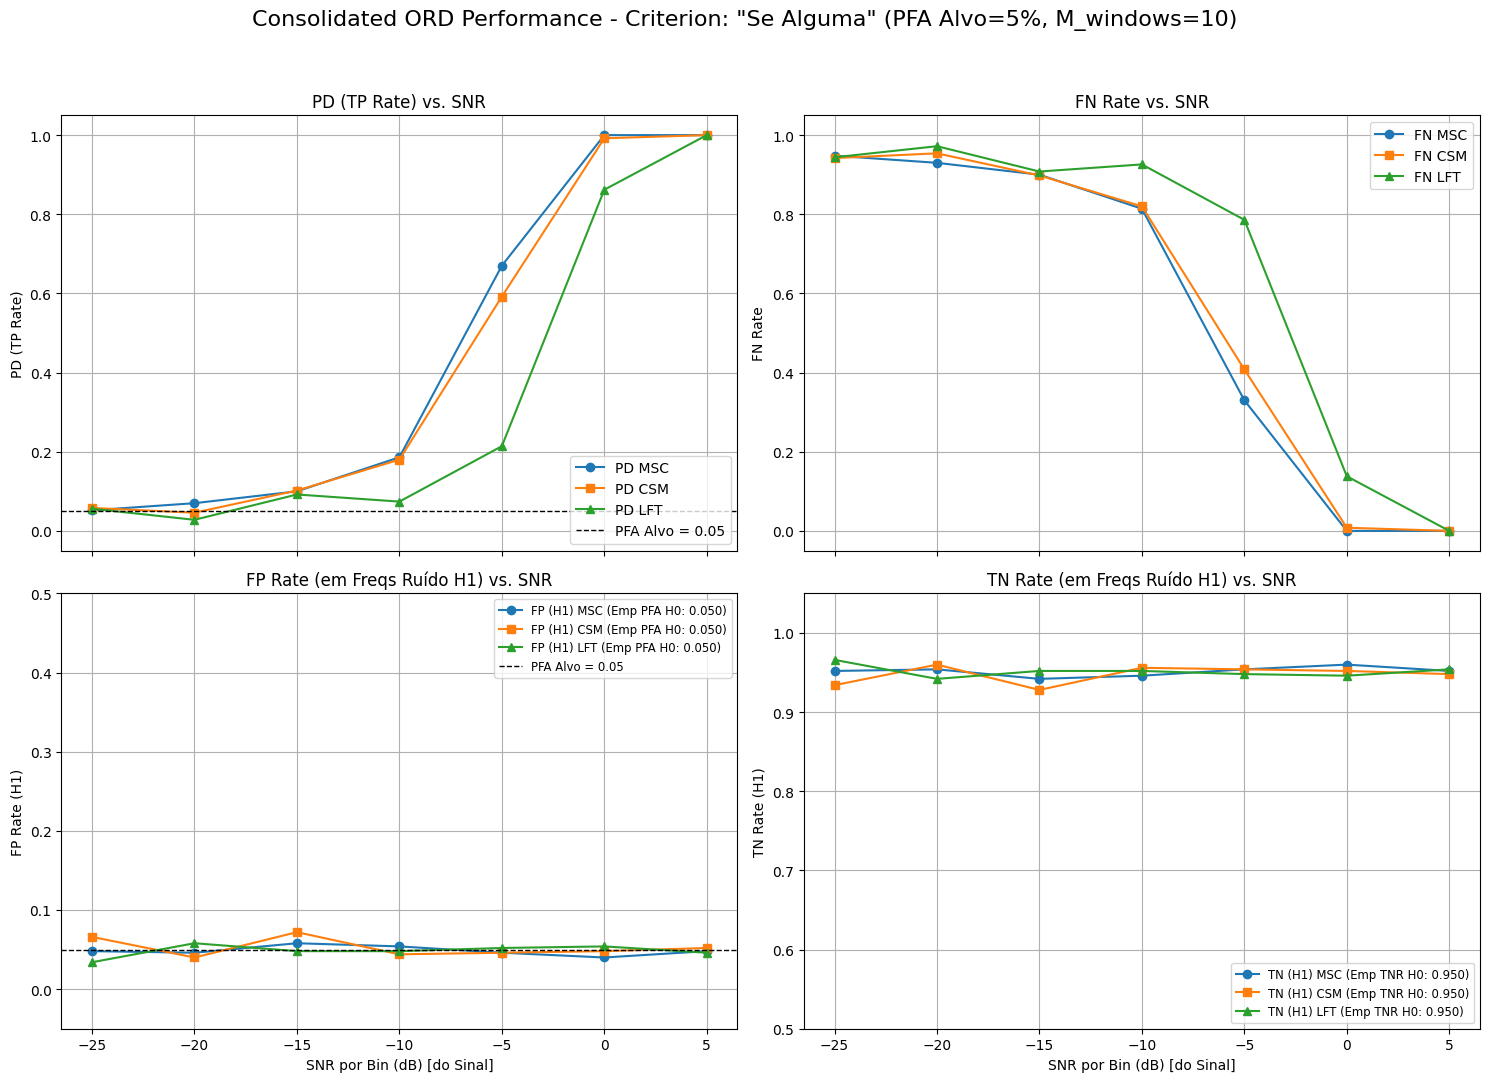

Simulação com múltiplas métricas e plot consolidado concluída.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, scoreatpercentile
import time

# --- Helper Functions (msc_fft_py, csm_fft_py, lft_fft_py, wilson_score_interval_py, adjust_freqs_get_bins_py as previously defined) ---
# (Ensure these functions are defined here or imported)
def msc_fft_py(Y_input, M_win): # ... (implementation from before)
    if Y_input.shape[1] == 0 or M_win == 0: return np.zeros(Y_input.shape[0])
    current_M_win = min(M_win, Y_input.shape[1])
    if current_M_win == 0: return np.zeros(Y_input.shape[0])
    if current_M_win == 1: return np.ones(Y_input.shape[0])
    Y_to_use = Y_input[:, :current_M_win]
    numerator = np.abs(np.sum(Y_to_use, axis=1))**2
    denominator = current_M_win * np.sum(np.abs(Y_to_use)**2, axis=1)
    msc = np.zeros_like(numerator, dtype=float)
    valid_den_mask = denominator != 0
    msc[valid_den_mask] = numerator[valid_den_mask] / denominator[valid_den_mask]
    msc[np.isnan(msc)] = 0; msc[np.isinf(msc)] = 0
    return msc

def csm_fft_py(Y_fft_all_windows, M_win_dummy): # ... (implementation from before)
    if Y_fft_all_windows.shape[1] == 0: return np.zeros(Y_fft_all_windows.shape[0])
    phases = np.angle(Y_fft_all_windows)
    mean_cos = np.mean(np.cos(phases), axis=1)
    mean_sin = np.mean(np.sin(phases), axis=1)
    csm_spectrum = mean_cos**2 + mean_sin**2
    csm_spectrum[np.isnan(csm_spectrum)] = 0
    return csm_spectrum

def lft_fft_py(Y_fft_all_windows, M_win_dummy, L_neighbors): # ... (implementation from before)
    if Y_fft_all_windows.shape[1] == 0: return np.zeros(Y_fft_all_windows.shape[0])
    power_spectrum_per_window = np.abs(Y_fft_all_windows)**2
    avg_power_spectrum = np.mean(power_spectrum_per_window, axis=1)
    num_bins = len(avg_power_spectrum)
    lft_spectrum = np.zeros(num_bins, dtype=float)
    for f_idx in range(num_bins):
        signal_power = avg_power_spectrum[f_idx]
        lower_indices = np.arange(max(0, f_idx - L_neighbors), f_idx)
        upper_indices = np.arange(f_idx + 1, min(num_bins, f_idx + L_neighbors + 1))
        all_neighbor_indices = np.unique(np.concatenate((lower_indices, upper_indices)).astype(int))
        if len(all_neighbor_indices) < L_neighbors : 
            mean_noise_power = 1e-12
        else:
            noise_power_bins = avg_power_spectrum[all_neighbor_indices]
            mean_noise_power = np.mean(noise_power_bins) if len(noise_power_bins) > 0 else 1e-12
        if mean_noise_power < 1e-12: 
            lft_spectrum[f_idx] = signal_power / 1e-12
        else:
            lft_spectrum[f_idx] = signal_power / mean_noise_power
    lft_spectrum[np.isnan(lft_spectrum)] = 0
    non_inf_max = np.max(lft_spectrum[~np.isinf(lft_spectrum)], initial=1e6)
    lft_spectrum[np.isinf(lft_spectrum)] = non_inf_max if non_inf_max > 0 else 1e6
    return lft_spectrum

def wilson_score_interval_py(k, n, confidence_level=0.95): # ... (implementation from before)
    if n == 0 or np.isnan(n) or np.isnan(k) or n < k: return np.nan, (np.nan, np.nan)
    k = np.nan_to_num(float(k)); n = float(n)
    alpha = 1 - confidence_level; z = norm.ppf(1 - alpha / 2)
    phat = k / n
    term1_num = phat + (z**2) / (2 * n)
    term2_num = z * np.sqrt((phat * (1 - phat) / n) + (z**2) / (4 * n**2))
    denominator = 1 + (z**2) / n
    pci_l = max(0, (term1_num - term2_num) / denominator)
    pci_u = min(1, (term1_num + term2_num) / denominator)
    return phat, (pci_l, pci_u)

def adjust_freqs_get_bins_py(nominal_freqs, NFFT_val, FS_rate): # ... (implementation from before)
    adj_freqs = np.zeros_like(nominal_freqs, dtype=float)
    bin_indices = np.zeros_like(nominal_freqs, dtype=int)
    for i, f_val in enumerate(nominal_freqs):
        bin_idx_ideal = int(round(f_val * NFFT_val / FS_rate))
        adj_freqs[i] = bin_idx_ideal * FS_rate / NFFT_val
        bin_indices[i] = bin_idx_ideal 
    return adj_freqs, bin_indices


# --- Simulation Parameters ---
FS = 1000; NFFT = 512; M_windows = 10
signal_frequencies_nominal = np.array([82, 84, 86, 88, 90, 92, 94, 96])
noise_only_frequencies_nominal = np.array([41, 51, 61, 71, 101, 111, 121, 131])
fp_reference_frequencies_nominal = noise_only_frequencies_nominal.copy()

num_signal_freqs = len(signal_frequencies_nominal)
num_noise_only_freqs = len(noise_only_frequencies_nominal)
num_fp_ref_freqs = len(fp_reference_frequencies_nominal)

target_pfa = 0.05
N_trials_H0 = 5000
N_master_trials_H1 = 500
snr_db_per_bin_range = np.arange(-25, 5 + 1, 5)
L_neighbors_lft = 2

total_samples = NFFT * M_windows
t_segment = np.arange(NFFT) / FS
hanning_win = np.hanning(NFFT)

signal_frequencies_adj, signal_bin_indices_py = adjust_freqs_get_bins_py(signal_frequencies_nominal, NFFT, FS)
noise_only_frequencies_adj, noise_only_bin_indices_py = adjust_freqs_get_bins_py(noise_only_frequencies_nominal, NFFT, FS)
fp_reference_frequencies_adj, fp_ref_bin_indices_py = adjust_freqs_get_bins_py(fp_reference_frequencies_nominal, NFFT, FS)

print(f"Signal Freqs Adjusted: {signal_frequencies_adj}")
# ... (other prints)

metrics_to_run = ['MSC', 'CSM', 'LFT']
num_metrics = len(metrics_to_run)
aggregated_results_se_alguma_py = [] # List to store dicts for each metric

sigma_n_sq_time = 1.0
P_n_bin_expected = (2.0 / NFFT) * sigma_n_sq_time

for metric_name in metrics_to_run:
    print(f"\n--- Processing Metric: {metric_name} ---")
    # ... (H0 Threshold Determination as before) ...
    start_time_h0 = time.time()
    max_metric_values_H0 = np.zeros(N_trials_H0)
    for i in range(N_trials_H0):
        noise_all_windows_H0 = np.sqrt(sigma_n_sq_time) * np.random.randn(total_samples)
        Y_fft_H0_all_windows = np.zeros((NFFT // 2 + 1, M_windows), dtype=complex)
        for k_win in range(M_windows):
            start_idx = k_win * NFFT; end_idx = (k_win + 1) * NFFT
            Y_fft_H0_all_windows[:, k_win] = np.fft.rfft(noise_all_windows_H0[start_idx:end_idx] * hanning_win)
        
        metric_spectrum_H0 = None
        if metric_name == 'MSC': metric_spectrum_H0 = msc_fft_py(Y_fft_H0_all_windows, M_windows)
        elif metric_name == 'CSM': metric_spectrum_H0 = csm_fft_py(Y_fft_H0_all_windows, M_windows)
        elif metric_name == 'LFT': metric_spectrum_H0 = lft_fft_py(Y_fft_H0_all_windows, M_windows, L_neighbors_lft)

        valid_indices_h0 = fp_ref_bin_indices_py[(fp_ref_bin_indices_py >= 0) & (fp_ref_bin_indices_py < len(metric_spectrum_H0))]
        if metric_spectrum_H0 is not None and len(valid_indices_h0) == num_fp_ref_freqs:
            max_metric_values_H0[i] = np.max(metric_spectrum_H0[valid_indices_h0])
        else: max_metric_values_H0[i] = np.nan
    valid_metric_H0 = max_metric_values_H0[~np.isnan(max_metric_values_H0)]
    threshold_metric = scoreatpercentile(valid_metric_H0, (1 - target_pfa) * 100)
    pfa_empirical_global_H0_metric = np.sum(valid_metric_H0 > threshold_metric) / len(valid_metric_H0)
    tn_rate_global_H0_metric = 1 - pfa_empirical_global_H0_metric
    end_time_h0 = time.time()
    print(f'Threshold {metric_name}: {threshold_metric:.4f} (PFA Emp H0: {pfa_empirical_global_H0_metric:.4f})')


    # --- Part 2: H1 Calculations (as before, storing in results_H1_metric dict) ---
    criteria_names = ['Média', 'Se Alguma', 'Se Maioria', 'Se Todas']
    num_criteria = len(criteria_names)
    results_H1_metric_temp = {} # Temporary for current metric
    for name in criteria_names:
        results_H1_metric_temp[name] = {
            'PD': np.zeros(len(snr_db_per_bin_range)), 'FN_Rate': np.zeros(len(snr_db_per_bin_range)),
            'FP_Rate_H1': np.zeros(len(snr_db_per_bin_range)), 'TN_Rate_H1': np.zeros(len(snr_db_per_bin_range)),
        } # Simplified, not storing ICs here for brevity, but you can add them
    
    # ... (H1 loop over SNR and master_trials, populating results_H1_metric_temp)
    print(f'Calculating PD/FN & FP_H1/TN_H1 for {metric_name}...')
    start_time_h1_total = time.time()
    for snr_idx, current_snr_db in enumerate(snr_db_per_bin_range):
        current_snr_linear = 10**(current_snr_db / 10)
        P_s_bin_target = current_snr_linear * P_n_bin_expected
        A_signal = np.sqrt(2 * P_s_bin_target)
        counts_PD_agg = np.zeros(num_criteria, dtype=int)
        counts_FP_H1_agg = np.zeros(num_criteria, dtype=int)

        for master_trial in range(N_master_trials_H1):
            n_t_all_windows_master = np.sqrt(sigma_n_sq_time) * np.random.randn(total_samples)
            Y_fft_noise_master_all_windows = np.zeros((NFFT // 2 + 1, M_windows), dtype=complex)
            for k_win in range(M_windows):
                start_idx = k_win * NFFT; end_idx = (k_win + 1) * NFFT
                Y_fft_noise_master_all_windows[:, k_win] = np.fft.rfft(n_t_all_windows_master[start_idx:end_idx] * hanning_win)
            
            metric_spectrum_noise_master = None
            if metric_name == 'MSC': metric_spectrum_noise_master = msc_fft_py(Y_fft_noise_master_all_windows, M_windows)
            elif metric_name == 'CSM': metric_spectrum_noise_master = csm_fft_py(Y_fft_noise_master_all_windows, M_windows)
            elif metric_name == 'LFT': metric_spectrum_noise_master = lft_fft_py(Y_fft_noise_master_all_windows, M_windows, L_neighbors_lft)
            
            metric_at_noise_only_bins_master = metric_spectrum_noise_master[noise_only_bin_indices_py]
            fp_results_for_noise_bins_master = (metric_at_noise_only_bins_master > threshold_metric).astype(int)
            num_fp_in_noise_master_trial = np.sum(fp_results_for_noise_bins_master)
            counts_FP_H1_agg[0] += num_fp_in_noise_master_trial
            if num_fp_in_noise_master_trial > 0: counts_FP_H1_agg[1] += 1
            if num_fp_in_noise_master_trial > (num_noise_only_freqs / 2): counts_FP_H1_agg[2] += 1
            if num_fp_in_noise_master_trial == num_noise_only_freqs: counts_FP_H1_agg[3] += 1

            individual_signal_detections_this_master_trial_list = []
            for sig_f_idx in range(num_signal_freqs):
                s_t_single_window = A_signal * np.sin(2 * np.pi * signal_frequencies_adj[sig_f_idx] * t_segment)
                x_t_all_windows = np.tile(s_t_single_window, M_windows) + n_t_all_windows_master
                Y_fft_H1_all_windows = np.zeros((NFFT // 2 + 1, M_windows), dtype=complex)
                for k_win in range(M_windows):
                    start_idx = k_win * NFFT; end_idx = (k_win + 1) * NFFT
                    Y_fft_H1_all_windows[:, k_win] = np.fft.rfft(x_t_all_windows[start_idx:end_idx] * hanning_win)
                
                metric_spectrum_H1 = None
                if metric_name == 'MSC': metric_spectrum_H1 = msc_fft_py(Y_fft_H1_all_windows, M_windows)
                elif metric_name == 'CSM': metric_spectrum_H1 = csm_fft_py(Y_fft_H1_all_windows, M_windows)
                elif metric_name == 'LFT': metric_spectrum_H1 = lft_fft_py(Y_fft_H1_all_windows, M_windows, L_neighbors_lft)
                
                current_metric_at_signal_bin = metric_spectrum_H1[signal_bin_indices_py[sig_f_idx]]
                individual_signal_detections_this_master_trial_list.append(1 if not np.isnan(current_metric_at_signal_bin) and current_metric_at_signal_bin > threshold_metric else 0)
            
            num_detected_signals_in_master_trial = np.sum(individual_signal_detections_this_master_trial_list)
            counts_PD_agg[0] += num_detected_signals_in_master_trial
            if num_detected_signals_in_master_trial > 0: counts_PD_agg[1] += 1
            if num_detected_signals_in_master_trial > (num_signal_freqs / 2): counts_PD_agg[2] += 1
            if num_detected_signals_in_master_trial == num_signal_freqs: counts_PD_agg[3] += 1
            
        n_PD_denominators = [N_master_trials_H1 * num_signal_freqs, N_master_trials_H1, N_master_trials_H1, N_master_trials_H1]
        n_FP_H1_denominators = [N_master_trials_H1 * num_noise_only_freqs, N_master_trials_H1, N_master_trials_H1, N_master_trials_H1]
        for c_idx, crit_name in enumerate(criteria_names):
            pd_val, _ = wilson_score_interval_py(counts_PD_agg[c_idx], n_PD_denominators[c_idx])
            results_H1_metric_temp[crit_name]['PD'][snr_idx] = pd_val
            results_H1_metric_temp[crit_name]['FN_Rate'][snr_idx] = 1 - pd_val if not np.isnan(pd_val) else np.nan
            fp_val, _ = wilson_score_interval_py(counts_FP_H1_agg[c_idx], n_FP_H1_denominators[c_idx])
            results_H1_metric_temp[crit_name]['FP_Rate_H1'][snr_idx] = fp_val
            results_H1_metric_temp[crit_name]['TN_Rate_H1'][snr_idx] = 1 - fp_val if not np.isnan(fp_val) else np.nan
        # print(f'  SNR={current_snr_db:.1f}dB ({metric_name}): PD_M={results_H1_metric_temp["Média"]["PD"][snr_idx]:.3f}')
    end_time_h1_total = time.time()
    print(f'Time total H1 for {metric_name}: {end_time_h1_total - start_time_h1_total:.2f}s')


    # Store "Se Alguma" results for the current metric
    current_metric_agg_data_py = {
        'name': metric_name,
        'pfa_empirical_H0': pfa_empirical_global_H0_metric,
        'tn_rate_H0': tn_rate_global_H0_metric,
        'PD': results_H1_metric_temp['Se Alguma']['PD'],
        'FN_Rate': results_H1_metric_temp['Se Alguma']['FN_Rate'],
        'FP_Rate_H1': results_H1_metric_temp['Se Alguma']['FP_Rate_H1'],
        'TN_Rate_H1': results_H1_metric_temp['Se Alguma']['TN_Rate_H1']
    }
    aggregated_results_se_alguma_py.append(current_metric_agg_data_py)

    # Individual plotting (optional, can be commented out)
    # fig_ind, axs_ind = plt.subplots(2, 2, figsize=(12, 9), sharex=True)
    # ... (code for individual metric plot)
    # plt.show()


# --- Part 4: Consolidated Plotting for "Se Alguma" Criterion ---
print('--- Generating Consolidated Plot for "Se Alguma" Criterion ---')
fig_consolidated, axs_consolidated = plt.subplots(2, 2, figsize=(15, 11), sharex=True)
fig_consolidated.suptitle(f'Consolidated ORD Performance - Criterion: "Se Alguma" (PFA Alvo={target_pfa*100:.0f}%, M_windows={M_windows})', fontsize=16)

plot_styles_metrics = ['-o', '-s', '-^', '-d', '-v', '-<']
prop_cycle = plt.rcParams['axes.prop_cycle']
metric_colors = prop_cycle.by_key()['color']

# PD Plot
ax = axs_consolidated[0,0]
for m_idx, data in enumerate(aggregated_results_se_alguma_py):
    ax.plot(snr_db_per_bin_range, data['PD'], plot_styles_metrics[m_idx % len(plot_styles_metrics)],
            color=metric_colors[m_idx % len(metric_colors)], linewidth=1.5, label=f"PD {data['name']}")
ax.axhline(target_pfa, color='k', linestyle='--', linewidth=1, label=f'PFA Alvo = {target_pfa:.2f}')
ax.set_title('PD (TP Rate) vs. SNR')
ax.set_ylabel('PD (TP Rate)'); ax.grid(True); ax.legend(loc='lower right'); ax.set_ylim([-0.05, 1.05])

# FN Plot
ax = axs_consolidated[0,1]
for m_idx, data in enumerate(aggregated_results_se_alguma_py):
    ax.plot(snr_db_per_bin_range, data['FN_Rate'], plot_styles_metrics[m_idx % len(plot_styles_metrics)],
            color=metric_colors[m_idx % len(metric_colors)], linewidth=1.5, label=f"FN {data['name']}")
ax.set_title('FN Rate vs. SNR')
ax.set_ylabel('FN Rate'); ax.grid(True); ax.legend(loc='upper right'); ax.set_ylim([-0.05, 1.05])

# FP (H1) Plot
ax = axs_consolidated[1,0]
for m_idx, data in enumerate(aggregated_results_se_alguma_py):
    ax.plot(snr_db_per_bin_range, data['FP_Rate_H1'], plot_styles_metrics[m_idx % len(plot_styles_metrics)],
            color=metric_colors[m_idx % len(metric_colors)], linewidth=1.5,
            label=f"FP (H1) {data['name']} (Emp PFA H0: {data['pfa_empirical_H0']:.3f})")
ax.axhline(target_pfa, color='k', linestyle='--', linewidth=1, label=f'PFA Alvo = {target_pfa:.2f}')
ax.set_title('FP Rate (em Freqs Ruído H1) vs. SNR')
ax.set_ylabel('FP Rate (H1)'); ax.set_xlabel('SNR por Bin (dB) [do Sinal]'); ax.grid(True);
ax.legend(loc='upper right', fontsize='small'); ax.set_ylim([-0.05, 0.5])

# TN (H1) Plot
ax = axs_consolidated[1,1]
for m_idx, data in enumerate(aggregated_results_se_alguma_py):
    ax.plot(snr_db_per_bin_range, data['TN_Rate_H1'], plot_styles_metrics[m_idx % len(plot_styles_metrics)],
            color=metric_colors[m_idx % len(metric_colors)], linewidth=1.5,
            label=f"TN (H1) {data['name']} (Emp TNR H0: {data['tn_rate_H0']:.3f})")
ax.set_title('TN Rate (em Freqs Ruído H1) vs. SNR')
ax.set_ylabel('TN Rate (H1)'); ax.set_xlabel('SNR por Bin (dB) [do Sinal]'); ax.grid(True);
ax.legend(loc='lower right', fontsize='small'); ax.set_ylim([0.5, 1.05])

plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust for suptitle
plt.show()

print('Simulação com múltiplas métricas e plot consolidado concluída.')


===== Processing for M_MAX_WINDOWS = 20 =====

--- Metric: MSC ---
H0 phase for MSC (M_MAX=20)...
  MSC (M_MAX=20): Threshold (Single Test) = 0.2298 (Empirical PFA_single = 0.0500)
  Re-evaluating H0 for sequential tests with threshold=0.2298...
    NDC=1: PFA_seq(H0)=1.0000, Avg_ATL_seq(H0)=1.00 windows
    NDC=2: PFA_seq(H0)=0.6180, Avg_ATL_seq(H0)=9.74 windows
    NDC=3: PFA_seq(H0)=0.3060, Avg_ATL_seq(H0)=15.55 windows
H1 phase for MSC (M_MAX=20)...
    SNR=-20.0dB: PD_single=0.012, PD_seq(NDC=1)=1.000 (example), Avg_ATL_seq(NDC=1)=1.00
    SNR=-15.0dB: PD_single=0.020, PD_seq(NDC=1)=1.000 (example), Avg_ATL_seq(NDC=1)=1.00
    SNR=-10.0dB: PD_single=0.108, PD_seq(NDC=1)=1.000 (example), Avg_ATL_seq(NDC=1)=1.00
    SNR=-5.0dB: PD_single=0.362, PD_seq(NDC=1)=1.000 (example), Avg_ATL_seq(NDC=1)=1.00
    SNR=0.0dB: PD_single=0.952, PD_seq(NDC=1)=1.000 (example), Avg_ATL_seq(NDC=1)=1.00

--- Metric: CSM ---
H0 phase for CSM (M_MAX=20)...
  CSM (M_MAX=20): Threshold (Single Test) = 0.2

TypeError: '<' not supported between instances of 'int' and 'str'

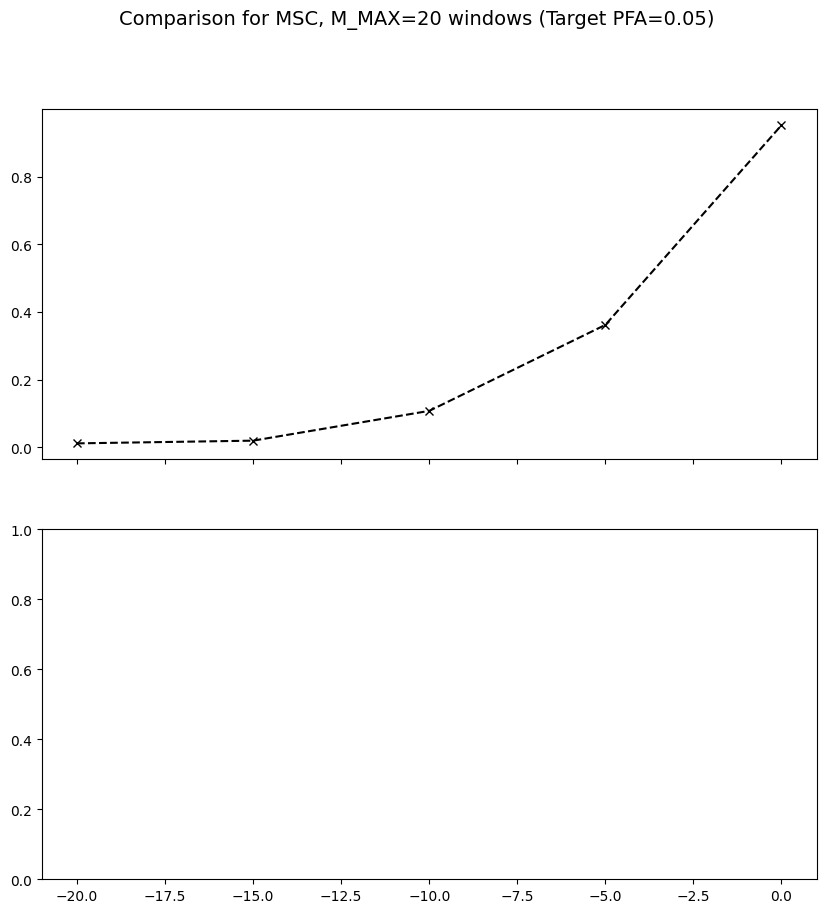

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, scoreatpercentile
import time
import pandas as pd # For easier results handling

# --- ORD Helper Functions (msc_fft_py, csm_fft_py, lft_fft_py) ---
# --- wilson_score_interval_py, adjust_freqs_get_bins_py ---
# [Ensure these functions are defined here from previous responses]
def msc_fft_py(Y_input, M_win):
    if Y_input.shape[1] == 0 or M_win == 0: return np.zeros(Y_input.shape[0])
    current_M_win = min(M_win, Y_input.shape[1])
    if current_M_win == 0: return np.zeros(Y_input.shape[0])
    if current_M_win == 1: return np.ones(Y_input.shape[0]) # MSC is 1 for M=1 if defined
    Y_to_use = Y_input[:, :current_M_win]
    numerator = np.abs(np.sum(Y_to_use, axis=1))**2
    denominator = current_M_win * np.sum(np.abs(Y_to_use)**2, axis=1)
    msc = np.zeros_like(numerator, dtype=float)
    valid_den_mask = denominator != 0
    msc[valid_den_mask] = numerator[valid_den_mask] / denominator[valid_den_mask]
    msc[np.isnan(msc)] = 0; msc[np.isinf(msc)] = 0
    return msc

def csm_fft_py(Y_fft_all_windows, M_win_dummy):
    if Y_fft_all_windows.shape[1] == 0: return np.zeros(Y_fft_all_windows.shape[0])
    phases = np.angle(Y_fft_all_windows)
    mean_cos = np.mean(np.cos(phases), axis=1)
    mean_sin = np.mean(np.sin(phases), axis=1)
    csm_spectrum = mean_cos**2 + mean_sin**2
    csm_spectrum[np.isnan(csm_spectrum)] = 0
    return csm_spectrum

def lft_fft_py(Y_fft_all_windows, M_win_dummy, L_neighbors):
    if Y_fft_all_windows.shape[1] == 0: return np.zeros(Y_fft_all_windows.shape[0])
    power_spectrum_per_window = np.abs(Y_fft_all_windows)**2
    avg_power_spectrum = np.mean(power_spectrum_per_window, axis=1)
    num_bins = len(avg_power_spectrum)
    lft_spectrum = np.zeros(num_bins, dtype=float)
    for f_idx in range(num_bins):
        signal_power = avg_power_spectrum[f_idx]
        lower_indices = np.arange(max(0, f_idx - L_neighbors), f_idx)
        upper_indices = np.arange(f_idx + 1, min(num_bins, f_idx + L_neighbors + 1))
        all_neighbor_indices = np.unique(np.concatenate((lower_indices, upper_indices)).astype(int))
        
        valid_neighbors = all_neighbor_indices[(all_neighbor_indices >= 0) & (all_neighbor_indices < num_bins)]
        if len(valid_neighbors) < L_neighbors / 2 : # Heuristic: need at least some neighbors
             mean_noise_power = 1e-12
        else:
            noise_power_bins = avg_power_spectrum[valid_neighbors]
            mean_noise_power = np.mean(noise_power_bins) if len(noise_power_bins) > 0 else 1e-12

        if mean_noise_power < 1e-12: lft_spectrum[f_idx] = signal_power / 1e-12
        else: lft_spectrum[f_idx] = signal_power / mean_noise_power
            
    lft_spectrum[np.isnan(lft_spectrum)] = 0
    non_inf_max = np.max(lft_spectrum[~np.isinf(lft_spectrum)], initial=1e6)
    lft_spectrum[np.isinf(lft_spectrum)] = non_inf_max if non_inf_max > 0 else 1e6
    return lft_spectrum

def wilson_score_interval_py(k, n, confidence_level=0.95):
    if n == 0 or np.isnan(n) or np.isnan(k) or n < k: return np.nan, (np.nan, np.nan)
    k = np.nan_to_num(float(k)); n = float(n)
    alpha = 1 - confidence_level; z = norm.ppf(1 - alpha / 2)
    phat = k / n
    term1_num = phat + (z**2) / (2 * n)
    term2_num = z * np.sqrt((phat * (1 - phat) / n) + (z**2) / (4 * n**2))
    denominator = 1 + (z**2) / n
    pci_l = max(0, (term1_num - term2_num) / denominator)
    pci_u = min(1, (term1_num + term2_num) / denominator)
    return phat, (pci_l, pci_u)

def adjust_freqs_get_bins_py(nominal_freqs, NFFT_val, FS_rate):
    adj_freqs = np.zeros_like(nominal_freqs, dtype=float)
    bin_indices = np.zeros_like(nominal_freqs, dtype=int)
    for i, f_val in enumerate(nominal_freqs):
        bin_idx_ideal = int(round(f_val * NFFT_val / FS_rate))
        adj_freqs[i] = bin_idx_ideal * FS_rate / NFFT_val
        bin_indices[i] = bin_idx_ideal 
    return adj_freqs, bin_indices


# --- Simulation Parameters ---
FS = 1000; NFFT = 512;
# M_MAX_WINDOWS will be the key parameter for single test and upper limit for sequential
# M_MAX_WINDOWS_OPTIONS = [10, 20, 30] # Example: Test for different total data lengths
M_MAX_WINDOWS_OPTIONS = [20] # For a quicker focused run initially
L_neighbors_lft = 2

signal_frequencies_nominal = np.array([82]) # Single target frequency for simplicity in sequential logic
# signal_frequencies_nominal = np.array([82, 84, 86, 88, 90, 92, 94, 96]) # For multi-freq
fp_reference_frequencies_nominal = np.array([41, 51, 61, 71, 101, 111, 121, 131]) # For H0 thresholding

num_signal_freqs = len(signal_frequencies_nominal) # Will be 1 for this simplified example

target_pfa = 0.05
N_trials_H0 = 2000  # Increase for better threshold/PFA estimation
N_trials_H1 = 500   # Increase for smoother PD/ATL curves

snr_db_per_bin_range = np.arange(-20, 0 + 1, 5) # Coarser for demo

# Sequential Test Parameters
NDC_OPTIONS = [1, 2, 3] # Number of Consecutive Detections
M_STEP = 1 # Evaluate after every M_STEP windows

hanning_win = np.hanning(NFFT)
sigma_n_sq_time = 1.0
P_n_bin_expected = (2.0 / NFFT) * sigma_n_sq_time


# --- Get ORD Function ---
def get_ord_value(Y_fft_data_all_wins, current_m_windows, ord_name, target_bin_index, L_neigh_lft=2):
    """Calculates the ORD value for the specified bin using current_m_windows."""
    if current_m_windows == 0: return np.nan
    
    # Ensure Y_fft_data_all_wins has data up to current_m_windows
    # Y_fft_data_all_wins is (num_freq_bins, total_max_windows)
    # We need to select (num_freq_bins, current_m_windows)
    Y_to_process = Y_fft_data_all_wins[:, :current_m_windows]

    metric_spectrum = np.array([])
    if ord_name == 'MSC':
        metric_spectrum = msc_fft_py(Y_to_process, current_m_windows)
    elif ord_name == 'CSM':
        metric_spectrum = csm_fft_py(Y_to_process, current_m_windows)
    elif ord_name == 'LFT':
        metric_spectrum = lft_fft_py(Y_to_process, current_m_windows, L_neigh_lft)
    
    if target_bin_index < len(metric_spectrum):
        return metric_spectrum[target_bin_index]
    return np.nan

# --- Sequential Test Logic ---
def run_sequential_test(Y_fft_trial_data, ord_name, threshold, target_bin, M_MIN, M_MAX, NDC, L_lft=2):
    """
    Runs a single sequential test trial.
    Y_fft_trial_data: (num_freq_bins, M_MAX) pre-generated FFT data for the trial.
    Returns: (detected (bool), num_windows_used (int))
    """
    consecutive_detections = 0
    
    for m_current in range(1, M_MAX + 1): # Iterate window by window
        if m_current < M_MIN: # Don't make decision before M_MIN
            # Still calculate ORD if needed for NDC history, but don't count towards NDC yet IF m_current < M_MIN
            # For simplicity here, we start checking for NDC satisfaction right away if m_current >= M_MIN
            # A more robust M_MIN might be NDC itself or slightly more. Let's set M_MIN = NDC for now.
            if m_current < NDC : # Need at least NDC windows to have NDC consecutive detections
                continue


        ord_val = get_ord_value(Y_fft_trial_data, m_current, ord_name, target_bin, L_lft)

        if not np.isnan(ord_val) and ord_val > threshold:
            consecutive_detections += 1
        else:
            consecutive_detections = 0 # Reset if below threshold or NaN

        if consecutive_detections >= NDC:
            return True, m_current # Detected

    return False, M_MAX # Not detected within M_MAX windows

# --- Main Simulation Loop ---
metrics_to_run = ['MSC', 'CSM', 'LFT']
all_results = []

for M_MAX_CURRENT in M_MAX_WINDOWS_OPTIONS:
    print(f"\n===== Processing for M_MAX_WINDOWS = {M_MAX_CURRENT} =====")
    total_samples_max = NFFT * M_MAX_CURRENT
    
    # Adjust frequencies and get bins
    signal_frequencies_adj, signal_bin_indices_py = adjust_freqs_get_bins_py(signal_frequencies_nominal, NFFT, FS)
    fp_reference_frequencies_adj, fp_ref_bin_indices_py = adjust_freqs_get_bins_py(fp_reference_frequencies_nominal, NFFT, FS)
    
    # For this example, assuming single target frequency for sequential test logic simplicity
    # If multiple, the sequential logic needs to handle combined decision or track each.
    # We will use the first signal frequency for the sequential test demonstration.
    if num_signal_freqs > 0:
        target_signal_bin_sequential = signal_bin_indices_py[0]
    else: # Should not happen with current setup
        target_signal_bin_sequential = -1 


    for metric_name in metrics_to_run:
        print(f"\n--- Metric: {metric_name} ---")
        
        # 1. H0 Simulation for Threshold (using M_MAX_CURRENT for single test)
        #    and to evaluate PFA_sequential & ATL_H0_sequential
        print(f"H0 phase for {metric_name} (M_MAX={M_MAX_CURRENT})...")
        max_metric_values_H0_single = np.zeros(N_trials_H0)
        
        # For sequential H0 stats
        h0_seq_detections = {} # key: NDC, value: count
        h0_seq_atl = {}      # key: NDC, value: list of windows used

        for ndc_val in NDC_OPTIONS:
            h0_seq_detections[ndc_val] = 0
            h0_seq_atl[ndc_val] = []

        # Determine threshold using the *reference frequencies* for H0
        # The threshold is based on the max ORD value over these reference frequencies in each H0 trial
        # when using M_MAX_CURRENT windows (single test definition of threshold)
        
        h0_ord_values_at_ref_freqs_for_threshold = np.full((N_trials_H0, len(fp_ref_bin_indices_py)), np.nan)

        for i in range(N_trials_H0):
            noise_all_windows_H0 = np.sqrt(sigma_n_sq_time) * np.random.randn(NFFT * M_MAX_CURRENT) # Max data
            Y_fft_H0_trial_all_windows = np.zeros((NFFT // 2 + 1, M_MAX_CURRENT), dtype=complex)
            for k_win in range(M_MAX_CURRENT):
                start_idx = k_win * NFFT; end_idx = (k_win + 1) * NFFT
                Y_fft_H0_trial_all_windows[:, k_win] = np.fft.rfft(noise_all_windows_H0[start_idx:end_idx] * hanning_win)

            # For threshold calculation (single test based on M_MAX_CURRENT windows at fp_reference_frequencies)
            temp_max_at_ref_freqs = -np.inf
            for ref_bin_idx, actual_ref_bin in enumerate(fp_ref_bin_indices_py):
                 ord_val_ref = get_ord_value(Y_fft_H0_trial_all_windows, M_MAX_CURRENT, metric_name, actual_ref_bin, L_neighbors_lft)
                 if not np.isnan(ord_val_ref) and ord_val_ref > temp_max_at_ref_freqs:
                     temp_max_at_ref_freqs = ord_val_ref
            if temp_max_at_ref_freqs > -np.inf :
                 max_metric_values_H0_single[i] = temp_max_at_ref_freqs
            else: # Should not happen if fp_ref_bin_indices_py is valid
                 max_metric_values_H0_single[i] = np.nan


            # Evaluate sequential test PFA using one of the fp_reference_frequencies as the "target" for H0 sequential
            # This is a simplification: ideally, sequential PFA considers "any" of the reference frequencies being detected.
            # For now, let's pick the first fp_reference_frequency for sequential H0 evaluation.
            # A more rigorous sequential H0 PFA would run the sequential test logic across *all* fp_reference_frequencies
            # and count a trial as a false positive if *any* of them were detected sequentially.
            # Here, we test against a single, pre-defined noise bin for sequential H0.
            target_h0_seq_bin = fp_ref_bin_indices_py[0] if len(fp_ref_bin_indices_py) > 0 else 0


            for ndc_val in NDC_OPTIONS:
                m_min_current = ndc_val # Simplification: M_MIN = NDC
                detected_seq, windows_used_seq = run_sequential_test(Y_fft_H0_trial_all_windows, metric_name, -1, # Threshold placeholder
                                                                     target_h0_seq_bin, m_min_current, M_MAX_CURRENT, ndc_val, L_neighbors_lft)
                # Note: The threshold isn't used yet in run_sequential_test for this placeholder call
                # We will re-run with actual threshold later. This part is just to illustrate structure.
                # This needs to be done AFTER threshold is known.
                # Let's defer full H0 sequential evaluation until after threshold calc.


        valid_metric_H0_single = max_metric_values_H0_single[~np.isnan(max_metric_values_H0_single)]
        if len(valid_metric_H0_single) == 0:
            print(f"Warning: No valid H0 metric values for {metric_name} at M_MAX={M_MAX_CURRENT}. Skipping.")
            continue
        ord_threshold_single = scoreatpercentile(valid_metric_H0_single, (1 - target_pfa) * 100)
        pfa_empirical_H0_single = np.sum(valid_metric_H0_single > ord_threshold_single) / len(valid_metric_H0_single)
        print(f"  {metric_name} (M_MAX={M_MAX_CURRENT}): Threshold (Single Test) = {ord_threshold_single:.4f} (Empirical PFA_single = {pfa_empirical_H0_single:.4f})")

        # Now, re-evaluate H0 for sequential test PFA and ATL_H0 using the determined threshold
        print(f"  Re-evaluating H0 for sequential tests with threshold={ord_threshold_single:.4f}...")
        for i in range(N_trials_H0): # Re-use or re-generate H0 data
            noise_all_windows_H0 = np.sqrt(sigma_n_sq_time) * np.random.randn(NFFT * M_MAX_CURRENT)
            Y_fft_H0_trial_all_windows = np.zeros((NFFT // 2 + 1, M_MAX_CURRENT), dtype=complex)
            for k_win in range(M_MAX_CURRENT):
                start_idx = k_win * NFFT; end_idx = (k_win + 1) * NFFT
                Y_fft_H0_trial_all_windows[:, k_win] = np.fft.rfft(noise_all_windows_H0[start_idx:end_idx] * hanning_win)
            
            # For sequential H0 PFA: if any of the reference frequencies are detected sequentially.
            # This is complex because each ref freq needs its own sequential run.
            # Simplified approach: Use the first fp_reference_frequency as the target for evaluating PFA_seq.
            # This is an underestimation of the true multi-frequency sequential PFA.
            
            # A more accurate PFA_seq would involve:
            # For each H0 trial:
            #   max_ord_sequential_across_fp_ref_bins_for_this_trial = False
            #   min_windows_for_fp_this_trial = M_MAX_CURRENT
            #   For each fp_ref_bin in fp_ref_bin_indices_py:
            #     detected_seq_this_bin, windows_used_seq_this_bin = run_sequential_test(...)
            #     If detected_seq_this_bin:
            #       max_ord_sequential_across_fp_ref_bins_for_this_trial = True
            #       min_windows_for_fp_this_trial = min(min_windows_for_fp_this_trial, windows_used_seq_this_bin)
            #       break # one FP is enough for the trial
            #   If max_ord_sequential_across_fp_ref_bins_for_this_trial: h0_seq_detections[ndc_val] +=1
            #   h0_seq_atl[ndc_val].append(min_windows_for_fp_this_trial)

            # Using simplified PFA_seq based on ONE noise frequency bin for now
            target_h0_seq_bin = fp_ref_bin_indices_py[0] if len(fp_ref_bin_indices_py) > 0 else 0

            for ndc_val in NDC_OPTIONS:
                m_min_current = ndc_val 
                detected_seq, windows_used_seq = run_sequential_test(Y_fft_H0_trial_all_windows, metric_name, ord_threshold_single,
                                                                     target_h0_seq_bin, m_min_current, M_MAX_CURRENT, ndc_val, L_neighbors_lft)
                if detected_seq:
                    h0_seq_detections[ndc_val] += 1
                h0_seq_atl[ndc_val].append(windows_used_seq)
        
        for ndc_val in NDC_OPTIONS:
            pfa_seq_h0 = h0_seq_detections[ndc_val] / N_trials_H0 if N_trials_H0 > 0 else np.nan
            avg_atl_h0_seq = np.mean(h0_seq_atl[ndc_val]) if len(h0_seq_atl[ndc_val]) > 0 else np.nan
            print(f"    NDC={ndc_val}: PFA_seq(H0)={pfa_seq_h0:.4f}, Avg_ATL_seq(H0)={avg_atl_h0_seq:.2f} windows")
            all_results.append({
                'M_MAX': M_MAX_CURRENT, 'Metric': metric_name, 'SNR_dB': 'H0', 'NDC': ndc_val,
                'Test_Type': 'Sequential', 'PD_TPR': pfa_seq_h0, 'ATL_ANW': avg_atl_h0_seq,
                'Threshold': ord_threshold_single, 'PFA_Target': target_pfa,
                'PFA_Emp_Single_H0': pfa_empirical_H0_single
            })
        all_results.append({ # Store single test H0 PFA as a baseline
            'M_MAX': M_MAX_CURRENT, 'Metric': metric_name, 'SNR_dB': 'H0', 'NDC': 'N/A_Single',
            'Test_Type': 'Single', 'PD_TPR': pfa_empirical_H0_single, # This is PFA for H0
            'ATL_ANW': M_MAX_CURRENT, # ATL for single test under H0 is always M_MAX
            'Threshold': ord_threshold_single, 'PFA_Target': target_pfa
        })


        # 2. H1 Simulation for PD and ATL (Single vs Sequential)
        print(f"H1 phase for {metric_name} (M_MAX={M_MAX_CURRENT})...")
        for snr_db in snr_db_per_bin_range:
            current_snr_linear = 10**(snr_db / 10)
            P_s_bin_target = current_snr_linear * P_n_bin_expected
            A_signal = np.sqrt(2 * P_s_bin_target)

            h1_detections_single = 0
            h1_seq_detections = {ndc: 0 for ndc in NDC_OPTIONS}
            h1_seq_atl = {ndc: [] for ndc in NDC_OPTIONS}

            for i in range(N_trials_H1):
                # Generate signal + noise for M_MAX_CURRENT windows
                s_t_all_windows = np.zeros(NFFT * M_MAX_CURRENT)
                if num_signal_freqs > 0 and A_signal > 0 : # only add signal if Amplitude is >0
                    # For simplicity, using first signal frequency if multiple defined
                    # In a multi-frequency ASSR, signal would be sum of sinusoids
                    f_signal_adj = signal_frequencies_adj[0]
                    for k_win_master in range(M_MAX_CURRENT): # create signal for all M_MAX_CURRENT windows
                        t_segment_master = (np.arange(k_win_master*NFFT, (k_win_master+1)*NFFT)) / FS
                        s_t_all_windows[k_win_master*NFFT:(k_win_master+1)*NFFT] = A_signal * np.sin(2 * np.pi * f_signal_adj * (np.arange(NFFT)/FS) )


                noise_all_windows_H1 = np.sqrt(sigma_n_sq_time) * np.random.randn(NFFT * M_MAX_CURRENT)
                x_t_all_windows_H1 = s_t_all_windows + noise_all_windows_H1
                
                Y_fft_H1_trial_all_windows = np.zeros((NFFT // 2 + 1, M_MAX_CURRENT), dtype=complex)
                for k_win in range(M_MAX_CURRENT):
                    start_idx = k_win * NFFT; end_idx = (k_win + 1) * NFFT
                    Y_fft_H1_trial_all_windows[:, k_win] = np.fft.rfft(x_t_all_windows_H1[start_idx:end_idx] * hanning_win)

                # Single Test Evaluation (using M_MAX_CURRENT windows at target_signal_bin_sequential)
                ord_val_single = get_ord_value(Y_fft_H1_trial_all_windows, M_MAX_CURRENT, metric_name, target_signal_bin_sequential, L_neighbors_lft)
                if not np.isnan(ord_val_single) and ord_val_single > ord_threshold_single:
                    h1_detections_single += 1
                
                # Sequential Test Evaluation
                for ndc_val in NDC_OPTIONS:
                    m_min_current = ndc_val
                    detected_seq, windows_used_seq = run_sequential_test(Y_fft_H1_trial_all_windows, metric_name, ord_threshold_single,
                                                                         target_signal_bin_sequential, m_min_current, M_MAX_CURRENT, ndc_val, L_neighbors_lft)
                    if detected_seq:
                        h1_seq_detections[ndc_val] += 1
                    h1_seq_atl[ndc_val].append(windows_used_seq)
            
            # Record results for this SNR
            pd_single = h1_detections_single / N_trials_H1 if N_trials_H1 > 0 else np.nan
            all_results.append({
                'M_MAX': M_MAX_CURRENT, 'Metric': metric_name, 'SNR_dB': snr_db, 'NDC': 'N/A_Single',
                'Test_Type': 'Single', 'PD_TPR': pd_single, 'ATL_ANW': M_MAX_CURRENT,
                'Threshold': ord_threshold_single
            })

            for ndc_val in NDC_OPTIONS:
                pd_seq = h1_seq_detections[ndc_val] / N_trials_H1 if N_trials_H1 > 0 else np.nan
                avg_atl_h1_seq = np.mean(h1_seq_atl[ndc_val]) if len(h1_seq_atl[ndc_val]) > 0 else np.nan
                all_results.append({
                    'M_MAX': M_MAX_CURRENT, 'Metric': metric_name, 'SNR_dB': snr_db, 'NDC': ndc_val,
                    'Test_Type': 'Sequential', 'PD_TPR': pd_seq, 'ATL_ANW': avg_atl_h1_seq,
                    'Threshold': ord_threshold_single
                })
            print(f"    SNR={snr_db:.1f}dB: PD_single={pd_single:.3f}, PD_seq(NDC={NDC_OPTIONS[0]})={results_H1_metric_temp[criteria_names[1]]['PD'][snr_idx]:.3f} (example), Avg_ATL_seq(NDC={NDC_OPTIONS[0]})={np.mean(h1_seq_atl[NDC_OPTIONS[0]]):.2f}")


# --- Convert results to DataFrame and Plot ---
results_df = pd.DataFrame(all_results)
print("\nSimulation Results:")
print(results_df)

# --- Plotting ---
for m_max_plot in results_df['M_MAX'].unique():
    mmax_df = results_df[results_df['M_MAX'] == m_max_plot]
    for metric_plot in mmax_df['Metric'].unique():
        metric_df = mmax_df[mmax_df['Metric'] == metric_plot]
        
        snr_h1_df = metric_df[metric_df['SNR_dB'] != 'H0'] # Exclude H0 for PD plots
        snr_h0_df = metric_df[metric_df['SNR_dB'] == 'H0']

        fig, axs = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
        fig.suptitle(f"Comparison for {metric_plot}, M_MAX={m_max_plot} windows (Target PFA={target_pfa:.2f})", fontsize=14)

        # PD Plot
        ax1 = axs[0]
        single_test_h1_df = snr_h1_df[snr_h1_df['Test_Type'] == 'Single']
        if not single_test_h1_df.empty:
            ax1.plot(single_test_h1_df['SNR_dB'], single_test_h1_df['PD_TPR'], marker='x', linestyle='--', label='PD Single Test', color='black')

        for ndc_val in sorted(snr_h1_df['NDC'].unique()):
            if ndc_val == 'N/A_Single': continue
            seq_df_ndc = snr_h1_df[(snr_h1_df['Test_Type'] == 'Sequential') & (snr_h1_df['NDC'] == ndc_val)]
            if not seq_df_ndc.empty:
                ax1.plot(seq_df_ndc['SNR_dB'], seq_df_ndc['PD_TPR'], marker='o', label=f'PD Seq (NDC={ndc_val})')
        
        # Plot PFA for H0 on PD plot (as horizontal lines)
        single_test_h0_pfa = snr_h0_df[(snr_h0_df['Test_Type'] == 'Single')]['PD_TPR'].iloc[0] if not snr_h0_df[(snr_h0_df['Test_Type'] == 'Single')].empty else np.nan
        ax1.axhline(single_test_h0_pfa, linestyle=':', color='grey', label=f'PFA Single (Emp H0: {single_test_h0_pfa:.3f})')
        
        for ndc_val in sorted(snr_h0_df['NDC'].unique()):
            if ndc_val == 'N/A_Single': continue
            seq_h0_pfa_ndc = snr_h0_df[(snr_h0_df['Test_Type'] == 'Sequential') & (snr_h0_df['NDC'] == ndc_val)]['PD_TPR'].iloc[0] if not snr_h0_df[(snr_h0_df['Test_Type'] == 'Sequential') & (snr_h0_df['NDC'] == ndc_val)].empty else np.nan
            ax1.axhline(seq_h0_pfa_ndc, linestyle='-.', label=f'PFA Seq NDC={ndc_val} (Emp H0: {seq_h0_pfa_ndc:.3f})')
            
        ax1.set_ylabel('Probability of Detection (PD/TPR)')
        ax1.set_title('Detection Performance')
        ax1.legend(loc='lower right', fontsize='small'); ax1.grid(True); ax1.set_ylim([-0.05, 1.05])

        # ATL Plot
        ax2 = axs[1]
        if not single_test_h1_df.empty: # ATL for single test under H1 is always M_MAX
             ax2.plot(single_test_h1_df['SNR_dB'], single_test_h1_df['ATL_ANW'], marker='x', linestyle='--', label='ATL Single Test', color='black')

        for ndc_val in sorted(snr_h1_df['NDC'].unique()):
            if ndc_val == 'N/A_Single': continue
            seq_df_ndc = snr_h1_df[(snr_h1_df['Test_Type'] == 'Sequential') & (snr_h1_df['NDC'] == ndc_val)]
            if not seq_df_ndc.empty:
                ax2.plot(seq_df_ndc['SNR_dB'], seq_df_ndc['ATL_ANW'], marker='o', label=f'ATL Seq (NDC={ndc_val})')

        # Plot ATL for H0 (as horizontal lines)
        single_test_h0_atl = snr_h0_df[(snr_h0_df['Test_Type'] == 'Single')]['ATL_ANW'].iloc[0] if not snr_h0_df[(snr_h0_df['Test_Type'] == 'Single')].empty else np.nan
        ax2.axhline(single_test_h0_atl, linestyle=':', color='grey', label=f'ATL Single (H0): {single_test_h0_atl:.2f}')

        for ndc_val in sorted(snr_h0_df['NDC'].unique()):
            if ndc_val == 'N/A_Single': continue
            seq_h0_atl_ndc = snr_h0_df[(snr_h0_df['Test_Type'] == 'Sequential') & (snr_h0_df['NDC'] == ndc_val)]['ATL_ANW'].iloc[0] if not snr_h0_df[(snr_h0_df['Test_Type'] == 'Sequential') & (snr_h0_df['NDC'] == ndc_val)].empty else np.nan
            ax2.axhline(seq_h0_atl_ndc, linestyle='-.', label=f'ATL Seq NDC={ndc_val} (H0): {seq_h0_atl_ndc:.2f}')

        ax2.set_xlabel('SNR per Bin (dB)')
        ax2.set_ylabel('Average Test Length (Windows)')
        ax2.set_title('Test Efficiency')
        ax2.legend(loc='upper right', fontsize='small'); ax2.grid(True); ax2.set_ylim([0, m_max_plot + 5])
        
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

print("Sequential vs Single Test Simulation Complete.")

In [11]:
all_results

[{'M_MAX': 20,
  'Metric': 'MSC',
  'SNR_dB': 'H0',
  'NDC': 1,
  'Test_Type': 'Sequential',
  'PD_TPR': 1.0,
  'ATL_ANW': np.float64(1.0),
  'Threshold': np.float64(0.22979204890327593),
  'PFA_Target': 0.05,
  'PFA_Emp_Single_H0': np.float64(0.05)},
 {'M_MAX': 20,
  'Metric': 'MSC',
  'SNR_dB': 'H0',
  'NDC': 2,
  'Test_Type': 'Sequential',
  'PD_TPR': 0.618,
  'ATL_ANW': np.float64(9.737),
  'Threshold': np.float64(0.22979204890327593),
  'PFA_Target': 0.05,
  'PFA_Emp_Single_H0': np.float64(0.05)},
 {'M_MAX': 20,
  'Metric': 'MSC',
  'SNR_dB': 'H0',
  'NDC': 3,
  'Test_Type': 'Sequential',
  'PD_TPR': 0.306,
  'ATL_ANW': np.float64(15.546),
  'Threshold': np.float64(0.22979204890327593),
  'PFA_Target': 0.05,
  'PFA_Emp_Single_H0': np.float64(0.05)},
 {'M_MAX': 20,
  'Metric': 'MSC',
  'SNR_dB': 'H0',
  'NDC': 'N/A_Single',
  'Test_Type': 'Single',
  'PD_TPR': np.float64(0.05),
  'ATL_ANW': 20,
  'Threshold': np.float64(0.22979204890327593),
  'PFA_Target': 0.05},
 {'M_MAX': 20,
  

In [13]:
results_df

""


In [16]:
plot_df.index

Index([ 4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21,
       22, 23, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,
       44, 45, 46, 47, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65,
       66, 67, 68, 69, 70, 71],
      dtype='int64')

In [ ]:

# --- Convert to DataFrame and Basic Plotting ---
# This part should only be run AFTER the loops above are complete
results_df = pd.DataFrame(all_results)
print("\n--- Simulation Results Summary ---")
# ... (rest of the plotting code) ...

# --- Convert to DataFrame and Basic Plotting ---
# results_df = pd.DataFrame(all_results_list)
# print("\n--- Simulation Results Summary ---")
print(results_df.head(10)) # Print a bit more to see structure
# # results_df.to_csv("ord_simulation_results_comprehensive.csv", index=False) # Save results

# Basic Plotting (Example: PD vs SNR for a specific M_MAX)
sel_m_max = M_MAX_WINDOWS_OPTIONS[0]
plot_df = results_df[(results_df['M_MAX'] == sel_m_max) & (results_df['SNR_dB'] != 'H0')].copy() # Use .copy() to avoid SettingWithCopyWarning

# Convert SNR_dB to numeric for correct sorting on plots, coercing errors for 'H0' if it slips through
plot_df['SNR_dB_num'] = pd.to_numeric(plot_df['SNR_dB'], errors='coerce')


plt.figure(figsize=(14, 10)) # Wider figure for potentially many lines
for ord_id_plot in plot_df['ORD_ID'].unique():
    ord_df_specific_ord = plot_df[plot_df['ORD_ID'] == ord_id_plot].sort_values(by='SNR_dB_num')
    
    # Plot Single Test PD for this ORD config
    single_df = ord_df_specific_ord[ord_df_specific_ord['Test_Type'] == 'Single']
    if not single_df.empty:
        plt.plot(single_df['SNR_dB_num'], single_df['PD_TPR'], marker='x', linestyle='--', 
                 label=f'PD Single - {ord_id_plot}')
        
    # Get unique NDC values, excluding 'Single', and sort them as integers
    unique_ndc_values = sorted([ndc for ndc in ord_df_specific_ord['NDC'].unique() if isinstance(ndc, int)])

    for ndc_plot in unique_ndc_values:
        seq_ndc_df = ord_df_specific_ord[(ord_df_specific_ord['Test_Type'] == 'Sequential') & (ord_df_specific_ord['NDC'] == ndc_plot)]
        if not seq_ndc_df.empty:
            plt.plot(seq_ndc_df['SNR_dB_num'], seq_ndc_df['PD_TPR'], marker='o', 
                     label=f"PD Seq NDC={ndc_plot} - {ord_id_plot.split('_')[0]}")

plt.title(f'PD vs. SNR (M_MAX = {sel_m_max}, Target PFA ~ {target_pfa})')
plt.xlabel('SNR per Bin (dB)'); plt.ylabel('Probability of Detection (PD/TPR)')
plt.legend(fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left'); plt.grid(True); plt.ylim([-0.05, 1.05])
plt.tight_layout(rect=[0,0,0.75,1]) # Adjust for legend more
plt.show()


plt.figure(figsize=(14, 10)) # Wider figure
for ord_id_plot in plot_df['ORD_ID'].unique():
    ord_df_specific_ord = plot_df[plot_df['ORD_ID'] == ord_id_plot].sort_values(by='SNR_dB_num')
    
    single_df = ord_df_specific_ord[ord_df_specific_ord['Test_Type'] == 'Single']
    if not single_df.empty:
        plt.plot(single_df['SNR_dB_num'], single_df['ATL_ANW'], marker='x', linestyle='--', 
                 label=f'ATL Single - {ord_id_plot}')

    # Get unique NDC values, excluding 'Single', and sort them as integers
    unique_ndc_values = sorted([ndc for ndc in ord_df_specific_ord['NDC'].unique() if isinstance(ndc, int)])

    for ndc_plot in unique_ndc_values:
        seq_ndc_df = ord_df_specific_ord[(ord_df_specific_ord['Test_Type'] == 'Sequential') & (ord_df_specific_ord['NDC'] == ndc_plot)]
        if not seq_ndc_df.empty:
             plt.plot(seq_ndc_df['SNR_dB_num'], seq_ndc_df['ATL_ANW'], marker='o', 
                      label=f"ATL Seq NDC={ndc_plot} - {ord_id_plot.split('_')[0]}")

plt.title(f'Average Test Length (ATL) vs. SNR (M_MAX = {sel_m_max})')
plt.xlabel('SNR per Bin (dB)'); plt.ylabel('Average Test Length (Windows)')
plt.legend(fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left'); plt.grid(True); 
if not plot_df.empty: plt.ylim([0, plot_df['ATL_ANW'].max() + 5 if pd.notnull(plot_df['ATL_ANW'].max()) else sel_m_max + 5]) # Dynamic Ylim for ATL
else: plt.ylim([0, sel_m_max + 5])
plt.tight_layout(rect=[0,0,0.75,1]) # Adjust for legend more
plt.show()

print("Comprehensive Simulation Framework - Stage 1 Complete. Plotting fix applied.")


--- Simulation Results Summary ---
   M_MAX Metric SNR_dB         NDC   Test_Type  PD_TPR  ATL_ANW  Threshold  \
0     20    MSC     H0           1  Sequential   1.000    1.000   0.229792   
1     20    MSC     H0           2  Sequential   0.618    9.737   0.229792   
2     20    MSC     H0           3  Sequential   0.306   15.546   0.229792   
3     20    MSC     H0  N/A_Single      Single   0.050   20.000   0.229792   
4     20    MSC    -20  N/A_Single      Single   0.012   20.000   0.229792   
5     20    MSC    -20           1  Sequential   1.000    1.000   0.229792   
6     20    MSC    -20           2  Sequential   0.674    8.880   0.229792   
7     20    MSC    -20           3  Sequential   0.410   14.190   0.229792   
8     20    MSC    -15  N/A_Single      Single   0.020   20.000   0.229792   
9     20    MSC    -15           1  Sequential   1.000    1.000   0.229792   

   PFA_Target  PFA_Emp_Single_H0  
0        0.05               0.05  
1        0.05               0.05  


KeyError: 'ORD_ID'

<Figure size 1400x1000 with 0 Axes>


--- Simulation Results Summary ---
   M_MAX Metric SNR_dB         NDC   Test_Type  PD_TPR  ATL_ANW  Threshold  \
0     20    MSC     H0           1  Sequential   1.000    1.000   0.229792   
1     20    MSC     H0           2  Sequential   0.618    9.737   0.229792   
2     20    MSC     H0           3  Sequential   0.306   15.546   0.229792   
3     20    MSC     H0  N/A_Single      Single   0.050   20.000   0.229792   
4     20    MSC    -20  N/A_Single      Single   0.012   20.000   0.229792   
5     20    MSC    -20           1  Sequential   1.000    1.000   0.229792   
6     20    MSC    -20           2  Sequential   0.674    8.880   0.229792   
7     20    MSC    -20           3  Sequential   0.410   14.190   0.229792   
8     20    MSC    -15  N/A_Single      Single   0.020   20.000   0.229792   
9     20    MSC    -15           1  Sequential   1.000    1.000   0.229792   

   PFA_Target  PFA_Emp_Single_H0  
0        0.05               0.05  
1        0.05               0.05  


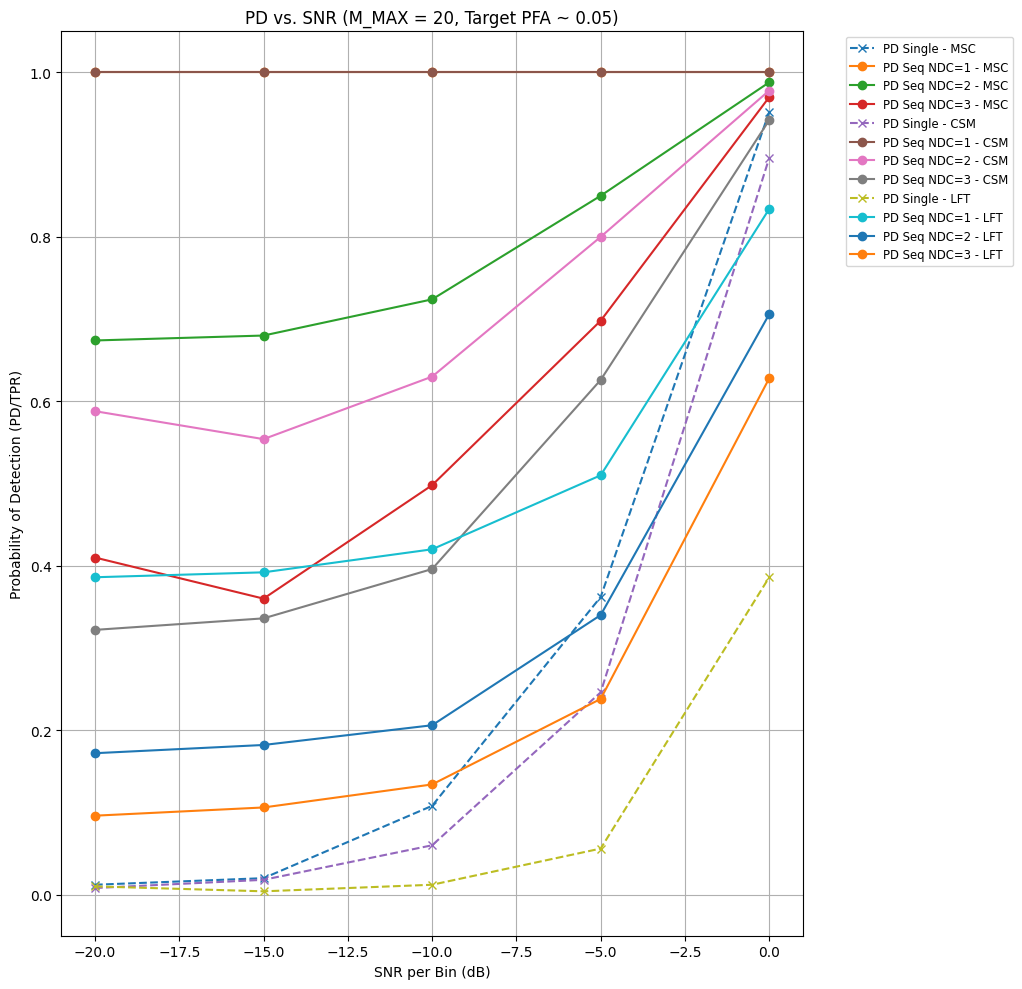

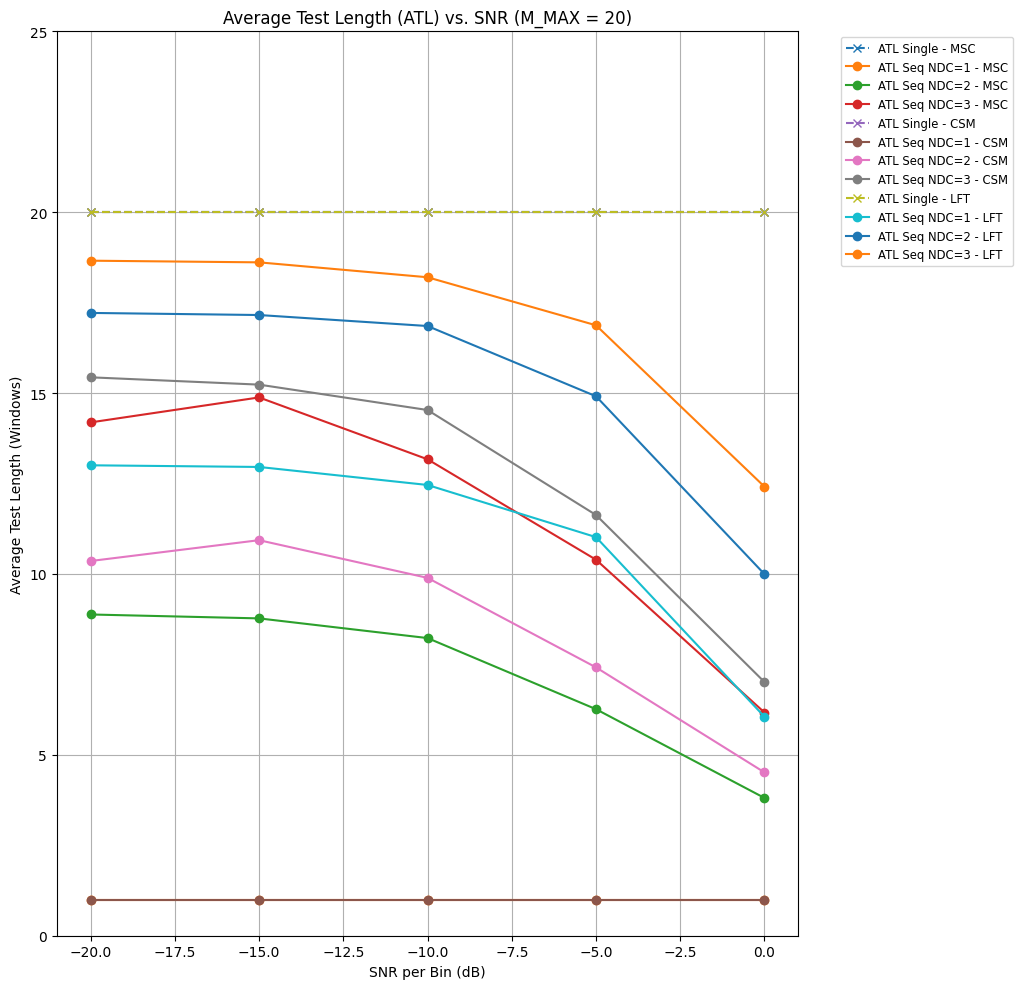

Plotting with 'Metric' key. Re-run simulation with 'ORD_ID' for full config differentiation.


In [18]:
all_results_list = all_results.copy()

# --- Convert to DataFrame and Basic Plotting ---
results_df = pd.DataFrame(all_results_list) # Assuming all_results_list is already populated as you showed
print("\n--- Simulation Results Summary ---")
print(results_df.head(10)) 
# results_df.to_csv("ord_simulation_results_current.csv", index=False) 

sel_m_max = results_df['M_MAX'].unique()[0] # Get the M_MAX from your data
plot_df = results_df[(results_df['M_MAX'] == sel_m_max) & (results_df['SNR_dB'] != 'H0')].copy()
plot_df['SNR_dB_num'] = pd.to_numeric(plot_df['SNR_dB'], errors='coerce')

plt.figure(figsize=(14, 10))
for metric_plot_val in plot_df['Metric'].unique(): # <--- CHANGED 'ORD_ID' to 'Metric'
    ord_df_specific_ord = plot_df[plot_df['Metric'] == metric_plot_val].sort_values(by='SNR_dB_num') # <--- CHANGED
    
    single_df = ord_df_specific_ord[ord_df_specific_ord['Test_Type'] == 'Single']
    if not single_df.empty:
        plt.plot(single_df['SNR_dB_num'], single_df['PD_TPR'], marker='x', linestyle='--', 
                 label=f'PD Single - {metric_plot_val}') # <--- CHANGED
        
    unique_ndc_values = sorted([ndc for ndc in ord_df_specific_ord['NDC'].unique() if isinstance(ndc, int)])
    for ndc_plot in unique_ndc_values:
        seq_ndc_df = ord_df_specific_ord[(ord_df_specific_ord['Test_Type'] == 'Sequential') & (ord_df_specific_ord['NDC'] == ndc_plot)]
        if not seq_ndc_df.empty:
            plt.plot(seq_ndc_df['SNR_dB_num'], seq_ndc_df['PD_TPR'], marker='o', 
                     label=f"PD Seq NDC={ndc_plot} - {metric_plot_val}") # <--- CHANGED (simplified label)

plt.title(f'PD vs. SNR (M_MAX = {sel_m_max}, Target PFA ~ {target_pfa if "target_pfa" in globals() else "N/A"})') # Check if target_pfa exists
plt.xlabel('SNR per Bin (dB)'); plt.ylabel('Probability of Detection (PD/TPR)')
plt.legend(fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left'); plt.grid(True); plt.ylim([-0.05, 1.05])
plt.tight_layout(rect=[0,0,0.75,1])
plt.show()

plt.figure(figsize=(14, 10))
for metric_plot_val in plot_df['Metric'].unique(): # <--- CHANGED
    ord_df_specific_ord = plot_df[plot_df['Metric'] == metric_plot_val].sort_values(by='SNR_dB_num') # <--- CHANGED
    
    single_df = ord_df_specific_ord[ord_df_specific_ord['Test_Type'] == 'Single']
    if not single_df.empty:
        plt.plot(single_df['SNR_dB_num'], single_df['ATL_ANW'], marker='x', linestyle='--', 
                 label=f'ATL Single - {metric_plot_val}') # <--- CHANGED

    unique_ndc_values = sorted([ndc for ndc in ord_df_specific_ord['NDC'].unique() if isinstance(ndc, int)])
    for ndc_plot in unique_ndc_values:
        seq_ndc_df = ord_df_specific_ord[(ord_df_specific_ord['Test_Type'] == 'Sequential') & (ord_df_specific_ord['NDC'] == ndc_plot)]
        if not seq_ndc_df.empty:
             plt.plot(seq_ndc_df['SNR_dB_num'], seq_ndc_df['ATL_ANW'], marker='o', 
                      label=f"ATL Seq NDC={ndc_plot} - {metric_plot_val}") # <--- CHANGED

plt.title(f'Average Test Length (ATL) vs. SNR (M_MAX = {sel_m_max})')
plt.xlabel('SNR per Bin (dB)'); plt.ylabel('Average Test Length (Windows)')
plt.legend(fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left'); plt.grid(True); 
if not plot_df.empty and 'ATL_ANW' in plot_df.columns and pd.notnull(plot_df['ATL_ANW'].max()): 
    plt.ylim([0, plot_df['ATL_ANW'].max() + 5])
else: 
    plt.ylim([0, (sel_m_max if isinstance(sel_m_max, (int, float)) else 20) + 5]) # Fallback if sel_m_max isn't simple number
plt.tight_layout(rect=[0,0,0.75,1])
plt.show()

print("Plotting with 'Metric' key. Re-run simulation with 'ORD_ID' for full config differentiation.")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, scoreatpercentile
import time
import pandas as pd
from collections import defaultdict

# --- ORD Helper Functions (msc_fft_py, csm_fft_py, lft_fft_py) ---
# [Ensure these are defined as in previous responses]
def msc_fft_py(Y_input, M_win):
    if Y_input.shape[1] == 0 or M_win == 0: return np.zeros(Y_input.shape[0]) # (bins,)
    current_M_win = min(M_win, Y_input.shape[1])
    if current_M_win == 0: return np.zeros(Y_input.shape[0])
    if current_M_win == 1: return np.ones(Y_input.shape[0])
    Y_to_use = Y_input[:, :current_M_win]
    numerator = np.abs(np.sum(Y_to_use, axis=1))**2
    denominator = current_M_win * np.sum(np.abs(Y_to_use)**2, axis=1)
    msc = np.zeros(Y_input.shape[0], dtype=float)
    valid_den_mask = denominator != 0
    msc[valid_den_mask] = numerator[valid_den_mask] / denominator[valid_den_mask]
    msc[np.isnan(msc)] = 0; msc[np.isinf(msc)] = 0
    return msc

def csm_fft_py(Y_fft_all_windows, M_win_dummy): # (bins, M_win)
    if Y_fft_all_windows.shape[1] == 0: return np.zeros(Y_fft_all_windows.shape[0])
    phases = np.angle(Y_fft_all_windows)
    mean_cos = np.mean(np.cos(phases), axis=1)
    mean_sin = np.mean(np.sin(phases), axis=1)
    csm_spectrum = mean_cos**2 + mean_sin**2
    csm_spectrum[np.isnan(csm_spectrum)] = 0
    return csm_spectrum # (bins,)

def lft_fft_py(Y_fft_all_windows_single_chan, M_win_dummy, L_neighbors): # (bins, M_win)
    if Y_fft_all_windows_single_chan.shape[1] == 0: return np.zeros(Y_fft_all_windows_single_chan.shape[0])
    power_spectrum_per_window = np.abs(Y_fft_all_windows_single_chan)**2
    avg_power_spectrum = np.mean(power_spectrum_per_window, axis=1) # (bins,)
    num_bins = len(avg_power_spectrum)
    lft_spectrum = np.zeros(num_bins, dtype=float)
    for f_idx in range(num_bins):
        signal_power = avg_power_spectrum[f_idx]
        lower_indices = np.arange(max(0, f_idx - L_neighbors), f_idx)
        upper_indices = np.arange(f_idx + 1, min(num_bins, f_idx + L_neighbors + 1))
        all_neighbor_indices = np.unique(np.concatenate((lower_indices, upper_indices)).astype(int))
        valid_neighbors = all_neighbor_indices[(all_neighbor_indices >= 0) & (all_neighbor_indices < num_bins)]
        
        if len(valid_neighbors) < L_neighbors / 2 : 
             mean_noise_power = 1e-12
        else:
            noise_power_bins = avg_power_spectrum[valid_neighbors]
            mean_noise_power = np.mean(noise_power_bins) if len(noise_power_bins) > 0 else 1e-12
        if mean_noise_power < 1e-12: lft_spectrum[f_idx] = signal_power / 1e-12
        else: lft_spectrum[f_idx] = signal_power / mean_noise_power
    lft_spectrum[np.isnan(lft_spectrum)] = 0
    non_inf_max = np.max(lft_spectrum[~np.isinf(lft_spectrum)], initial=1e6)
    lft_spectrum[np.isinf(lft_spectrum)] = non_inf_max if non_inf_max > 0 else 1e6
    return lft_spectrum # (bins,)

def gft_fft_py(Y_fft_all_windows_single_chan, target_bin_index, M_win, noise_bins_mask=None, NFFT_val=512):
    if M_win == 0 or Y_fft_all_windows_single_chan.shape[1] == 0: return np.nan
    power_spectrum_epochs = np.abs(Y_fft_all_windows_single_chan[:, :M_win])**2
    avg_power_spectrum = np.mean(power_spectrum_epochs, axis=1)
    if target_bin_index >= len(avg_power_spectrum): return np.nan
    signal_power = avg_power_spectrum[target_bin_index]
    num_total_bins = len(avg_power_spectrum)
    if noise_bins_mask is None:
        noise_bins_mask = np.ones(num_total_bins, dtype=bool)
        noise_bins_mask[target_bin_index] = False
        if 0 < num_total_bins : noise_bins_mask[0] = False 
        if num_total_bins > NFFT_val//2 : noise_bins_mask[NFFT_val//2] = False
    noise_power_values = avg_power_spectrum[noise_bins_mask]
    if len(noise_power_values) == 0: return np.nan
    mean_noise_power = np.mean(noise_power_values)
    if mean_noise_power < 1e-12: return signal_power / 1e-12
    gft_val = signal_power / mean_noise_power
    return gft_val if not np.isnan(gft_val) else 0.0

def ht2_fft_py(Y_fft_epoch_data_single_bin_M_win, M_win): # (M_win,) complex data
    if M_win < 2 : return np.nan
    Y_complex = Y_fft_epoch_data_single_bin_M_win.flatten()
    if len(Y_complex) != M_win: return np.nan
    data_2d = np.array([Y_complex.real, Y_complex.imag]).T
    try:
        mean_vector = np.mean(data_2d, axis=0)
        if M_win <= 2 : return 0.0 
        cov_matrix = np.cov(data_2d, rowvar=False)
        if np.linalg.matrix_rank(cov_matrix) < 2:
             return 1e6 if np.any(np.abs(mean_vector) > 1e-9) else 0.0
        inv_cov_matrix = np.linalg.inv(cov_matrix)
        t_squared = M_win * (mean_vector.T @ inv_cov_matrix @ mean_vector)
        return t_squared if not np.isnan(t_squared) else 0.0
    except np.linalg.LinAlgError: return 1e6 if np.any(np.abs(mean_vector) > 1e-9) else 0.0
    except Exception: return np.nan

# --- Correlated Noise and Utility Functions ---
def generate_correlated_noise_mc(num_samples_total, num_channels, sigma_sq_time, correlation_matrix):
    if correlation_matrix.shape[0] != num_channels or correlation_matrix.shape[1] != num_channels:
        raise ValueError("Correlation matrix dimensions must match num_channels.")
    std_dev = np.sqrt(sigma_sq_time)
    D = np.diag(np.full(num_channels, std_dev))
    covariance_matrix = D @ correlation_matrix @ D
    independent_noise = np.random.randn(num_channels, num_samples_total)
    try:
        L = np.linalg.cholesky(covariance_matrix)
        correlated_noise_transposed = L @ independent_noise
        return correlated_noise_transposed.T # (num_samples_total x num_channels)
    except np.linalg.LinAlgError:
        print("Warning: Cholesky decomposition failed for noise. Using independent noise.")
        return np.sqrt(sigma_sq_time) * np.random.randn(num_samples_total, num_channels)

def wilson_score_interval_py(k, n, confidence_level=0.95): # As before
    if n == 0 or np.isnan(n) or np.isnan(k) or n < k: return np.nan, (np.nan, np.nan)
    k = np.nan_to_num(float(k)); n = float(n)
    alpha = 1 - confidence_level; z = norm.ppf(1 - alpha / 2)
    phat = k / n
    term1_num = phat + (z**2) / (2 * n)
    term2_num = z * np.sqrt((phat * (1 - phat) / n) + (z**2) / (4 * n**2))
    denominator = 1 + (z**2) / n
    pci_l = max(0, (term1_num - term2_num) / denominator)
    pci_u = min(1, (term1_num + term2_num) / denominator)
    return phat, (pci_l, pci_u)

def adjust_freqs_get_bins_py(nominal_freqs, NFFT_val, FS_rate): # As before
    adj_freqs = np.zeros_like(nominal_freqs, dtype=float)
    bin_indices = np.zeros_like(nominal_freqs, dtype=int)
    for i, f_val in enumerate(nominal_freqs):
        bin_idx_ideal = int(round(f_val * NFFT_val / FS_rate))
        adj_freqs[i] = bin_idx_ideal * FS_rate / NFFT_val
        bin_indices[i] = bin_idx_ideal 
    return adj_freqs, bin_indices

# --- Enhanced ORD Calculation ---
def get_ord_value_enhanced(Y_fft_trial_data_all_channels, # (num_channels_sim, num_freq_bins, current_m_windows)
                           current_m_windows,
                           ord_config, # Dictionary defining the ORD
                           target_fundamental_bin_index, 
                           FS_rate, NFFT_val):
    if current_m_windows == 0: return np.nan
    
    base_ord_name = ord_config['base_ord']
    num_sim_channels = Y_fft_trial_data_all_channels.shape[0]
    num_ord_channels = ord_config.get('num_channels_for_ord', num_sim_channels)
    
    # Select channels to use for ORD (e.g. for 'MSC_ch1' from a 2-channel sim)
    # This assumes channels for ORD are the first `num_ord_channels` of simulated channels
    # A more flexible selection (e.g., specific channel indices) could be added.
    Y_data_for_ord_calc = Y_fft_trial_data_all_channels[:num_ord_channels, :, :current_m_windows]

    ord_values_per_channel_after_q = []

    for chan_idx in range(num_ord_channels):
        Y_chan_data = Y_data_for_ord_calc[chan_idx, :, :] # (num_freq_bins, current_m_windows)
        
        harmonic_bins_to_eval = [target_fundamental_bin_index]
        if ord_config.get('q_num_harmonics', 0) > 0:
            fundamental_freq_hz = target_fundamental_bin_index * FS_rate / NFFT_val
            for h_num in range(1, ord_config['q_num_harmonics'] + 1):
                harmonic_freq_ideal = fundamental_freq_hz * (h_num + 1)
                harmonic_bin = int(round(harmonic_freq_ideal * NFFT_val / FS_rate))
                # Ensure harmonic_bin is within valid range (0 to NFFT//2) and distinct
                if 0 <= harmonic_bin <= NFFT_val // 2 and harmonic_bin not in harmonic_bins_to_eval:
                    harmonic_bins_to_eval.append(harmonic_bin)
        harmonic_bins_to_eval = sorted(list(set(harmonic_bins_to_eval)))

        ord_stats_for_harmonics_this_channel = []
        for bin_idx_eval in harmonic_bins_to_eval:
            ord_stat_one_bin = np.nan
            if base_ord_name == 'MSC':
                ord_stat_one_bin = msc_fft_py(Y_chan_data[bin_idx_eval, :].reshape(1, current_m_windows), current_m_windows)[0]
            elif base_ord_name == 'CSM':
                ord_stat_one_bin = csm_fft_py(Y_chan_data[bin_idx_eval, :].reshape(1, current_m_windows), current_m_windows)[0]
            elif base_ord_name == 'HT2':
                ord_stat_one_bin = ht2_fft_py(Y_chan_data[bin_idx_eval, :], current_m_windows) # Pass (M_win,)
            elif base_ord_name == 'LFT': # Needs full spectrum for this channel
                lft_spectrum_this_chan = lft_fft_py(Y_chan_data, current_m_windows, ord_config.get('L_lft', 2))
                if bin_idx_eval < len(lft_spectrum_this_chan): ord_stat_one_bin = lft_spectrum_this_chan[bin_idx_eval]
            elif base_ord_name == 'GFT': # Needs full spectrum for this channel
                ord_stat_one_bin = gft_fft_py(Y_chan_data, bin_idx_eval, current_m_windows, NFFT_val=NFFT_val)
            
            if not np.isnan(ord_stat_one_bin):
                ord_stats_for_harmonics_this_channel.append(ord_stat_one_bin)
        
        if not ord_stats_for_harmonics_this_channel:
            ord_values_per_channel_after_q.append(np.nan)
            continue

        q_combined_stat_this_channel = np.nan
        if ord_config.get('q_num_harmonics', 0) == 0 or len(ord_stats_for_harmonics_this_channel) == 1:
            q_combined_stat_this_channel = ord_stats_for_harmonics_this_channel[0]
        else:
            q_method = ord_config.get('q_combination', 'sum')
            if q_method == 'sum': q_combined_stat_this_channel = np.sum(ord_stats_for_harmonics_this_channel)
            elif q_method == 'average': q_combined_stat_this_channel = np.mean(ord_stats_for_harmonics_this_channel)
            elif q_method == 'product': q_combined_stat_this_channel = np.prod([max(s, 1e-9) for s in ord_stats_for_harmonics_this_channel])
            elif q_method == 'max': q_combined_stat_this_channel = np.max(ord_stats_for_harmonics_this_channel)
        ord_values_per_channel_after_q.append(q_combined_stat_this_channel)

    valid_ord_values_post_q = [s for s in ord_values_per_channel_after_q if not np.isnan(s)]
    if not valid_ord_values_post_q: return np.nan

    final_ord_value = np.nan
    if num_ord_channels == 1 or not ord_config.get('channel_combination') or len(valid_ord_values_post_q) ==1 :
        final_ord_value = valid_ord_values_post_q[0]
    else:
        chan_combo_method = ord_config['channel_combination']
        if chan_combo_method == 'average': final_ord_value = np.mean(valid_ord_values_post_q)
        elif chan_combo_method == 'product': final_ord_value = np.prod([max(s, 1e-9) for s in valid_ord_values_post_q]) ** (1.0 / len(valid_ord_values_post_q))
        elif chan_combo_method == 'max': final_ord_value = np.max(valid_ord_values_post_q)
            
    return final_ord_value

# --- Sequential Test Logic (Enhanced) ---
def run_sequential_test_enhanced(Y_fft_trial_data_all_channels, ord_config_dict, threshold, 
                                 target_fundamental_bin, M_MIN, M_MAX, NDC, FS, NFFT_val_seq):
    consecutive_detections = 0
    for m_current in range(1, M_MAX + 1):
        if m_current < M_MIN: continue
        
        ord_val = get_ord_value_enhanced(Y_fft_trial_data_all_channels, m_current, ord_config_dict, 
                                         target_fundamental_bin, FS, NFFT_val_seq)
        
        if not np.isnan(ord_val) and ord_val > threshold:
            consecutive_detections += 1
        else:
            consecutive_detections = 0
        
        if consecutive_detections >= NDC:
            return True, m_current
    return False, M_MAX

# --- Simulation Parameters ---
FS = 1000; NFFT = 512;
L_neighbors_lft = 2 

NUM_CHANNELS_SIM = 2 # Max channels to simulate
CHANNEL_CORRELATION = 0.5 # Example, use 0 for independent
if NUM_CHANNELS_SIM == 1:
    correlation_matrix_sim = np.array([[1.0]])
elif NUM_CHANNELS_SIM == 2:
    correlation_matrix_sim = np.array([[1.0, CHANNEL_CORRELATION], [CHANNEL_CORRELATION, 1.0]])
else: # Needs definition for >2
    correlation_matrix_sim = np.eye(NUM_CHANNELS_SIM) 
print(f"Simulating with {NUM_CHANNELS_SIM} channel(s), Correlation Matrix:\n{correlation_matrix_sim}")

signal_frequencies_nominal = np.array([82]) # Single target for simplicity
fp_reference_frequencies_nominal = np.array([41, 51, 61, 71, 101, 111, 121, 131])

target_pfa = 0.05
N_trials_H0 = 1000 # Reduce for faster dev, increase for accuracy
N_trials_H1 = 200  # Reduce for faster dev

M_MAX_WINDOWS_OPTIONS = [20] # Test with one M_MAX first
snr_db_per_bin_range = np.arange(-20, 0 + 1, 10) # Coarse SNR for speed
NDC_OPTIONS = [1, 3] 
M_STEP = 1 # Not explicitly used if M_MIN is based on NDC

hanning_win = np.hanning(NFFT)
sigma_n_sq_time = 1.0
P_n_bin_expected = (2.0 / NFFT) * sigma_n_sq_time

# --- ORD Configurations ---
ord_configurations_to_run = [
    {'id': 'MSC_ch1_f0', 'base_ord': 'MSC', 'num_channels_for_ord': 1, 'q_num_harmonics': 0},
    {'id': 'CSM_ch1_f0', 'base_ord': 'CSM', 'num_channels_for_ord': 1, 'q_num_harmonics': 0},
    {'id': 'LFT_ch1_f0', 'base_ord': 'LFT', 'num_channels_for_ord': 1, 'q_num_harmonics': 0, 'L_lft': L_neighbors_lft},
    {'id': 'HT2_ch1_f0', 'base_ord': 'HT2', 'num_channels_for_ord': 1, 'q_num_harmonics': 0},
    {'id': 'GFT_ch1_f0', 'base_ord': 'GFT', 'num_channels_for_ord': 1, 'q_num_harmonics': 0},
    {'id': 'qSumMSC_ch1_h1', 'base_ord': 'MSC', 'num_channels_for_ord': 1, 'q_num_harmonics': 1, 'q_combination': 'sum'},
]
if NUM_CHANNELS_SIM >= 2:
    ord_configurations_to_run.extend([
        {'id': 'aMSC_2ch_f0', 'base_ord': 'MSC', 'num_channels_for_ord': 2, 'channel_combination': 'average', 'q_num_harmonics': 0},
        {'id': 'pCSM_2ch_f0', 'base_ord': 'CSM', 'num_channels_for_ord': 2, 'channel_combination': 'product', 'q_num_harmonics': 0},
        {'id': 'qProd_aLFT_2ch_h1', 'base_ord': 'LFT', 'num_channels_for_ord': 2, 'channel_combination': 'average', 
         'q_num_harmonics': 1, 'q_combination':'product', 'L_lft': L_neighbors_lft},
    ])

# --- Main Simulation ---
all_results_list = []
signal_frequencies_adj, signal_bin_indices_py = adjust_freqs_get_bins_py(signal_frequencies_nominal, NFFT, FS)
fp_reference_frequencies_adj, fp_ref_bin_indices_py = adjust_freqs_get_bins_py(fp_reference_frequencies_nominal, NFFT, FS)
target_signal_bin_fundamental = signal_bin_indices_py[0] if len(signal_bin_indices_py) > 0 else -1


for M_MAX_CURRENT in M_MAX_WINDOWS_OPTIONS:
    print(f"\n===== M_MAX_WINDOWS = {M_MAX_CURRENT} =====")
    
    for ord_config in ord_configurations_to_run:
        current_ord_id = ord_config['id']
        print(f"\n--- ORD Config: {current_ord_id} (Base: {ord_config['base_ord']}) ---")

        # 1. H0 Thresholding & Sequential PFA/ATL_H0
        print(f"H0 phase for {current_ord_id}...")
        max_ord_values_H0_single_trials = np.full(N_trials_H0, np.nan)
        h0_seq_detections_counts = defaultdict(int)
        h0_seq_atl_lists = defaultdict(list)

        for i_h0 in range(N_trials_H0):
            noise_mc_h0 = generate_correlated_noise_mc(NFFT * M_MAX_CURRENT, NUM_CHANNELS_SIM, sigma_n_sq_time, correlation_matrix_sim)
            Y_fft_H0_trial_all_ch = np.zeros((NUM_CHANNELS_SIM, NFFT // 2 + 1, M_MAX_CURRENT), dtype=complex)
            for ch_idx in range(NUM_CHANNELS_SIM):
                for k_win in range(M_MAX_CURRENT):
                    start = k_win * NFFT; end = (k_win + 1) * NFFT
                    Y_fft_H0_trial_all_ch[ch_idx, :, k_win] = np.fft.rfft(noise_mc_h0[start:end, ch_idx] * hanning_win)
            
            # For single test threshold: max ORD over all fp_reference_bins (as fundamental)
            max_ord_this_h0_trial = -np.inf
            for fp_fund_bin in fp_ref_bin_indices_py:
                ord_val_h0 = get_ord_value_enhanced(Y_fft_H0_trial_all_ch, M_MAX_CURRENT, ord_config, fp_fund_bin, FS, NFFT)
                if not np.isnan(ord_val_h0) and ord_val_h0 > max_ord_this_h0_trial:
                    max_ord_this_h0_trial = ord_val_h0
            if max_ord_this_h0_trial > -np.inf: max_ord_values_H0_single_trials[i_h0] = max_ord_this_h0_trial
        
        valid_max_ord_H0 = max_ord_values_H0_single_trials[~np.isnan(max_ord_values_H0_single_trials)]
        if len(valid_max_ord_H0) < N_trials_H0 * 0.5 : # Check if enough valid trials
            print(f"Warning: Insufficient valid H0 trials for threshold for {current_ord_id}. Skipping.")
            continue
        ord_threshold_current_config = scoreatpercentile(valid_max_ord_H0, (1 - target_pfa) * 100)
        pfa_emp_single_H0 = np.sum(valid_max_ord_H0 > ord_threshold_current_config) / len(valid_max_ord_H0)
        print(f"  Threshold (Single Test): {ord_threshold_current_config:.4f} (Emp. PFA_single: {pfa_emp_single_H0:.4f})")

        # Re-evaluate H0 for sequential PFA/ATL with the derived threshold
        target_h0_seq_fund_bin = fp_ref_bin_indices_py[0] # Simplified PFA_seq target
        for i_h0_seq in range(N_trials_H0): # Can re-use H0 data or regenerate
            noise_mc_h0_seq = generate_correlated_noise_mc(NFFT * M_MAX_CURRENT, NUM_CHANNELS_SIM, sigma_n_sq_time, correlation_matrix_sim)
            Y_fft_H0_trial_all_ch_seq = np.zeros((NUM_CHANNELS_SIM, NFFT // 2 + 1, M_MAX_CURRENT), dtype=complex) # as above
            for ch_idx in range(NUM_CHANNELS_SIM):
                for k_win in range(M_MAX_CURRENT):
                    start = k_win * NFFT; end = (k_win + 1) * NFFT
                    Y_fft_H0_trial_all_ch_seq[ch_idx, :, k_win] = np.fft.rfft(noise_mc_h0_seq[start:end, ch_idx] * hanning_win)
            
            for ndc_val in NDC_OPTIONS:
                m_min_curr = max(1,ndc_val) # M_MIN at least 1, and at least NDC
                detected_seq, windows_used = run_sequential_test_enhanced(Y_fft_H0_trial_all_ch_seq, ord_config, 
                                                                          ord_threshold_current_config, target_h0_seq_fund_bin, 
                                                                          m_min_curr, M_MAX_CURRENT, ndc_val, FS, NFFT)
                if detected_seq: h0_seq_detections_counts[ndc_val] += 1
                h0_seq_atl_lists[ndc_val].append(windows_used)
        
        all_results_list.append({'ORD_ID': current_ord_id, 'M_MAX': M_MAX_CURRENT, 'SNR_dB': 'H0', 
                                 'NDC': 'Single', 'Test_Type': 'Single', 'PD_TPR': pfa_emp_single_H0, 
                                 'ATL_ANW': M_MAX_CURRENT, 'Threshold': ord_threshold_current_config})
        for ndc_val in NDC_OPTIONS:
            pfa_s = h0_seq_detections_counts[ndc_val] / N_trials_H0 if N_trials_H0 > 0 else np.nan
            atl_s_h0 = np.mean(h0_seq_atl_lists[ndc_val]) if h0_seq_atl_lists[ndc_val] else np.nan
            print(f"    NDC={ndc_val}: PFA_seq(H0)={pfa_s:.4f}, Avg_ATL_seq(H0)={atl_s_h0:.2f}")
            all_results_list.append({'ORD_ID': current_ord_id, 'M_MAX': M_MAX_CURRENT, 'SNR_dB': 'H0', 
                                     'NDC': ndc_val, 'Test_Type': 'Sequential', 'PD_TPR': pfa_s, 
                                     'ATL_ANW': atl_s_h0, 'Threshold': ord_threshold_current_config})

        # 2. H1 Phase
        print(f"H1 phase for {current_ord_id}...")
        for snr_db in snr_db_per_bin_range:
            current_snr_linear = 10**(snr_db / 10)
            P_s_bin_target = current_snr_linear * P_n_bin_expected
            A_signal = np.sqrt(2 * P_s_bin_target) if P_s_bin_target > 0 else 0

            h1_detections_single_count = 0
            h1_seq_detections_counts = defaultdict(int)
            h1_seq_atl_lists = defaultdict(list)

            for i_h1 in range(N_trials_H1):
                # Signal Generation (multi-channel)
                s_t_mc = np.zeros((NFFT * M_MAX_CURRENT, NUM_CHANNELS_SIM))
                if A_signal > 0 and target_signal_bin_fundamental != -1:
                    # Create base signal for fundamental frequency
                    t_total = np.arange(NFFT * M_MAX_CURRENT) / FS
                    f0_hz = target_signal_bin_fundamental * FS / NFFT
                    base_signal_f0 = A_signal * np.sin(2 * np.pi * f0_hz * t_total)
                    
                    # Add harmonics to base signal if q-ORD expects them (simplification: signal only on f0 and its harmonics)
                    # For a true q-ORD evaluation, the SNR definition would need to account for power in harmonics too.
                    # Here, SNR is defined for f0, harmonics are just "present" if A_signal > 0.
                    # This is a simplification; signal generation for q-ORDs should ideally distribute power across harmonics.

                    for ch_idx in range(NUM_CHANNELS_SIM): # Apply signal to all simulated channels
                        s_t_mc[:, ch_idx] = base_signal_f0 
                        # If q_num_harmonics > 0 in ord_config, could add signal harmonics here too
                        # e.g. if ord_config.get('q_num_harmonics',0) > 0 for h in ... A_signal_h * sin(2pi*f_h*t)

                noise_mc_h1 = generate_correlated_noise_mc(NFFT * M_MAX_CURRENT, NUM_CHANNELS_SIM, sigma_n_sq_time, correlation_matrix_sim)
                x_t_mc_h1 = s_t_mc + noise_mc_h1
                
                Y_fft_H1_trial_all_ch = np.zeros((NUM_CHANNELS_SIM, NFFT // 2 + 1, M_MAX_CURRENT), dtype=complex)
                for ch_idx in range(NUM_CHANNELS_SIM):
                    for k_win in range(M_MAX_CURRENT):
                        start = k_win * NFFT; end = (k_win + 1) * NFFT
                        Y_fft_H1_trial_all_ch[ch_idx, :, k_win] = np.fft.rfft(x_t_mc_h1[start:end, ch_idx] * hanning_win)

                # Single Test
                ord_val_h1_single = get_ord_value_enhanced(Y_fft_H1_trial_all_ch, M_MAX_CURRENT, ord_config, 
                                                           target_signal_bin_fundamental, FS, NFFT)
                if not np.isnan(ord_val_h1_single) and ord_val_h1_single > ord_threshold_current_config:
                    h1_detections_single_count += 1
                
                # Sequential Tests
                for ndc_val in NDC_OPTIONS:
                    m_min_curr = max(1,ndc_val)
                    detected_seq, windows_used = run_sequential_test_enhanced(Y_fft_H1_trial_all_ch, ord_config, 
                                                                              ord_threshold_current_config, target_signal_bin_fundamental,
                                                                              m_min_curr, M_MAX_CURRENT, ndc_val, FS, NFFT)
                    if detected_seq: h1_seq_detections_counts[ndc_val] += 1
                    h1_seq_atl_lists[ndc_val].append(windows_used)
            
            pd_single = h1_detections_single_count / N_trials_H1 if N_trials_H1 > 0 else np.nan
            all_results_list.append({'ORD_ID': current_ord_id, 'M_MAX': M_MAX_CURRENT, 'SNR_dB': snr_db, 
                                     'NDC': 'Single', 'Test_Type': 'Single', 'PD_TPR': pd_single, 
                                     'ATL_ANW': M_MAX_CURRENT, 'Threshold': ord_threshold_current_config})
            for ndc_val in NDC_OPTIONS:
                pd_s = h1_seq_detections_counts[ndc_val] / N_trials_H1 if N_trials_H1 > 0 else np.nan
                atl_s_h1 = np.mean(h1_seq_atl_lists[ndc_val]) if h1_seq_atl_lists[ndc_val] else np.nan
                all_results_list.append({'ORD_ID': current_ord_id, 'M_MAX': M_MAX_CURRENT, 'SNR_dB': snr_db, 
                                         'NDC': ndc_val, 'Test_Type': 'Sequential', 'PD_TPR': pd_s, 
                                         'ATL_ANW': atl_s_h1, 'Threshold': ord_threshold_current_config})
            print(f"    SNR={snr_db:.1f}dB: PD_single={pd_single:.3f}, PD_seq(NDC={NDC_OPTIONS[0]})={h1_seq_detections_counts[NDC_OPTIONS[0]]/N_trials_H1 if N_trials_H1>0 else np.nan:.3f}, Avg_ATL_seq(NDC={NDC_OPTIONS[0]})={np.mean(h1_seq_atl_lists[NDC_OPTIONS[0]]) if h1_seq_atl_lists[NDC_OPTIONS[0]] else np.nan:.2f}")

# --- Convert to DataFrame and Basic Plotting ---
results_df = pd.DataFrame(all_results_list)
print("\n--- Simulation Results Summary ---")
print(results_df.head())
# results_df.to_csv("ord_simulation_results_comprehensive.csv", index=False) # Save results

# Basic Plotting (Example: PD vs SNR for a specific M_MAX)
sel_m_max = M_MAX_WINDOWS_OPTIONS[0]
plot_df = results_df[(results_df['M_MAX'] == sel_m_max) & (results_df['SNR_dB'] != 'H0')]

plt.figure(figsize=(12, 8))
for ord_id_plot in plot_df['ORD_ID'].unique():
    ord_df = plot_df[plot_df['ORD_ID'] == ord_id_plot]
    
    # Plot Single Test PD for this ORD config
    single_df = ord_df[ord_df['Test_Type'] == 'Single']
    if not single_df.empty:
        plt.plot(pd.to_numeric(single_df['SNR_dB']), single_df['PD_TPR'], marker='x', linestyle='--', label=f'PD Single - {ord_id_plot}')
        
    # Plot Sequential Test PD for selected NDCs
    for ndc_plot in sorted(ord_df['NDC'].unique()):
        if ndc_plot == 'Single': continue # Already plotted
        seq_ndc_df = ord_df[(ord_df['Test_Type'] == 'Sequential') & (ord_df['NDC'] == ndc_plot)]
        if not seq_ndc_df.empty:
            plt.plot(pd.to_numeric(seq_ndc_df['SNR_dB']), seq_ndc_df['PD_TPR'], marker='o', 
                     label=f"PD Seq NDC={ndc_plot} - {ord_id_plot.split('_')[0]}") # Shorten label

plt.title(f'PD vs. SNR (M_MAX = {sel_m_max}, Target PFA ~ {target_pfa})')
plt.xlabel('SNR per Bin (dB)'); plt.ylabel('Probability of Detection (PD/TPR)')
plt.legend(fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left'); plt.grid(True); plt.ylim([-0.05, 1.05])
plt.tight_layout(rect=[0,0,0.8,1]) # Adjust for legend
plt.show()


plt.figure(figsize=(12, 8))
for ord_id_plot in plot_df['ORD_ID'].unique():
    ord_df = plot_df[plot_df['ORD_ID'] == ord_id_plot]
    single_df = ord_df[ord_df['Test_Type'] == 'Single']
    if not single_df.empty:
        plt.plot(pd.to_numeric(single_df['SNR_dB']), single_df['ATL_ANW'], marker='x', linestyle='--', label=f'ATL Single - {ord_id_plot}')
    for ndc_plot in sorted(ord_df['NDC'].unique()):
        if ndc_plot == 'Single': continue
        seq_ndc_df = ord_df[(ord_df['Test_Type'] == 'Sequential') & (ord_df['NDC'] == ndc_plot)]
        if not seq_ndc_df.empty:
             plt.plot(pd.to_numeric(seq_ndc_df['SNR_dB']), seq_ndc_df['ATL_ANW'], marker='o', 
                      label=f"ATL Seq NDC={ndc_plot} - {ord_id_plot.split('_')[0]}")

plt.title(f'Average Test Length (ATL) vs. SNR (M_MAX = {sel_m_max})')
plt.xlabel('SNR per Bin (dB)'); plt.ylabel('Average Test Length (Windows)')
plt.legend(fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left'); plt.grid(True); plt.ylim([0, sel_m_max + 5])
plt.tight_layout(rect=[0,0,0.8,1])
plt.show()

print("Comprehensive Simulation Framework - Stage 1 Complete.")